### ✨ TESTING ✨

In [ ]:
import unicodedata

def normalize_bangla(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200c", "")
    text = text.replace("\u200d", "")
    text = " ".join(text.split())
    return text

inputs = [
    "বড়লোকটি  ছেলেটিকে \u200cঅর্ধচন্দ্র  দিয়ে   বের করে  দিলেন",
    "মালিকের\u200c সামনে   বেশি\u200dবলায়\u200c   তাকে  অর্ধচন্দ্র \u200dপেতে\u00a0হলো",
    "অফিসে   দেরি  করায়\n   ম্যানেজার\u200c তাকে  অর্ধচন্দ্র \u200dদিলেন",
    "কৃষক\tঅর্ধচন্দ্র   দিয়ে \u200cঘাস \u200dকাটছে",
    "আমি  বাগানে \u200c\u200dঅর্ধচন্দ্র    দেখেছি"
]

print("INPUT:")
print("-" * 80)
for i, sentence in enumerate(inputs, 1):
    print(f"{i}. {sentence}")

print("OUTPUT:")
print("-" * 80)
for i, sentence in enumerate(inputs, 1):
    print(f"{i}. {normalize_bangla(sentence)}")

INPUT:
--------------------------------------------------------------------------------
1. বড়লোকটি  ছেলেটিকে ‌অর্ধচন্দ্র  দিয়ে   বের করে  দিলেন
2. মালিকের‌ সামনে   বেশি‍বলায়‌   তাকে  অর্ধচন্দ্র ‍পেতে হলো
3. অফিসে   দেরি  করায়
   ম্যানেজার‌ তাকে  অর্ধচন্দ্র ‍দিলেন
4. কৃষক	অর্ধচন্দ্র   দিয়ে ‌ঘাস ‍কাটছে
5. আমি  বাগানে ‌‍অর্ধচন্দ্র    দেখেছি
OUTPUT:
--------------------------------------------------------------------------------
1. বড়লোকটি ছেলেটিকে অর্ধচন্দ্র দিয়ে বের করে দিলেন
2. মালিকের সামনে বেশিবলায় তাকে অর্ধচন্দ্র পেতে হলো
3. অফিসে দেরি করায় ম্যানেজার তাকে অর্ধচন্দ্র দিলেন
4. কৃষক অর্ধচন্দ্র দিয়ে ঘাস কাটছে
5. আমি বাগানে অর্ধচন্দ্র দেখেছি


In [ ]:
import os
import numpy as np
import pickle
from scipy.sparse import load_npz

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

SPLIT_DIR    = os.path.join(PROJECT_ROOT, "02_splits")
LABELS_DIR   = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_ML_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")
TEXT_RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")

print("=" * 80)
print("📊 FEATURE EXTRACTION OUTPUT SUMMARY")
print("=" * 80)

print("\n" + "=" * 80)
print("1️⃣  DATASET SPLITS")
print("=" * 80)

train_idx = np.load(os.path.join(SPLIT_DIR, "train_idx.npy"))
val_idx   = np.load(os.path.join(SPLIT_DIR, "val_idx.npy"))
test_idx  = np.load(os.path.join(SPLIT_DIR, "test_idx.npy"))

print(f"\n📁 Split Directory: {SPLIT_DIR}")
print(f"\n   Train samples: {len(train_idx):,}")
print(f"   Val samples:   {len(val_idx):,}")
print(f"   Test samples:  {len(test_idx):,}")
print(f"   Total:         {len(train_idx) + len(val_idx) + len(test_idx):,}")

ratio_train = len(train_idx) / (len(train_idx) + len(val_idx) + len(test_idx)) * 100
ratio_val   = len(val_idx) / (len(train_idx) + len(val_idx) + len(test_idx)) * 100
ratio_test  = len(test_idx) / (len(train_idx) + len(val_idx) + len(test_idx)) * 100

print(f"\n   Split Ratio: {ratio_train:.1f}% / {ratio_val:.1f}% / {ratio_test:.1f}%")

print("\n" + "=" * 80)
print("2️⃣  LABELS DISTRIBUTION")
print("=" * 80)

y_train = np.load(os.path.join(LABELS_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABELS_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABELS_DIR, "y_test.npy"))

print(f"\n📁 Labels Directory: {LABELS_DIR}")

def show_label_dist(y, name):
    counts = np.bincount(y)
    print(f"\n   {name}:")
    for i, count in enumerate(counts):
        pct = count / len(y) * 100
        print(f"      Class {i}: {count:,} ({pct:.1f}%)")

show_label_dist(y_train, "Train")
show_label_dist(y_val,   "Validation")
show_label_dist(y_test,  "Test")

print("\n" + "=" * 80)
print("3️⃣  RAW TEXT FIELDS (DL/Transformers)")
print("=" * 80)

print(f"\n📁 Raw Text Directory: {TEXT_RAW_DIR}")
print("\n   Available splits:")

for split_name in ["train", "val", "test"]:
    split_path = os.path.join(TEXT_RAW_DIR, split_name)
    if os.path.exists(split_path):
        print(f"\n   • {split_name.upper()}:")
        for field in ["sentence", "idiom_word", "idiom_meaning"]:
            field_path = os.path.join(split_path, f"{field}.npy")
            if os.path.exists(field_path):
                data = np.load(field_path, allow_pickle=True)
                print(f"      - {field}.npy: {len(data):,} samples")
                # Show a sample
                if len(data) > 0:
                    sample = str(data[0])
                    if len(sample) > 60:
                        sample = sample[:60] + "..."
                    print(f"        Sample: {sample}")

print("\n" + "=" * 80)
print("4️⃣  ML FEATURES (TF-IDF - Three Fields)")
print("=" * 80)

print(f"\n📁 ML Features Directory: {FEAT_ML_THREE}")

X_train = load_npz(os.path.join(FEAT_ML_THREE, "X_train.npz"))
X_val   = load_npz(os.path.join(FEAT_ML_THREE, "X_val.npz"))
X_test  = load_npz(os.path.join(FEAT_ML_THREE, "X_test.npz"))

print(f"\n   Feature Matrix Shapes:")
print(f"      Train: {X_train.shape} ({X_train.nnz:,} non-zero values)")
print(f"      Val:   {X_val.shape} ({X_val.nnz:,} non-zero values)")
print(f"      Test:  {X_test.shape} ({X_test.nnz:,} non-zero values)")

print(f"\n   Sparsity:")
print(f"      Train: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")
print(f"      Val:   {(1 - X_val.nnz / (X_val.shape[0] * X_val.shape[1])) * 100:.2f}%")
print(f"      Test:  {(1 - X_test.nnz / (X_test.shape[0] * X_test.shape[1])) * 100:.2f}%")

with open(os.path.join(FEAT_ML_THREE, "sentence_vectorizer.pkl"), "rb") as f:
    vec_sent = pickle.load(f)
with open(os.path.join(FEAT_ML_THREE, "meaning_vectorizer.pkl"), "rb") as f:
    vec_mean = pickle.load(f)
with open(os.path.join(FEAT_ML_THREE, "idiom_vectorizer.pkl"), "rb") as f:
    vec_idm = pickle.load(f)

print(f"\n   Vectorizer Configurations:")
print(f"\n      Sentence Vectorizer:")
print(f"         - Analyzer: {vec_sent.analyzer}")
print(f"         - N-gram range: {vec_sent.ngram_range}")
print(f"         - Max features: {vec_sent.max_features}")
print(f"         - Vocabulary size: {len(vec_sent.vocabulary_):,}")

print(f"\n      Idiom Meaning Vectorizer:")
print(f"         - Analyzer: {vec_mean.analyzer}")
print(f"         - N-gram range: {vec_mean.ngram_range}")
print(f"         - Max features: {vec_mean.max_features}")
print(f"         - Vocabulary size: {len(vec_mean.vocabulary_):,}")

print(f"\n      Idiom Word Vectorizer:")
print(f"         - Analyzer: {vec_idm.analyzer}")
print(f"         - N-gram range: {vec_idm.ngram_range}")
print(f"         - Max features: {vec_idm.max_features}")
print(f"         - Vocabulary size: {len(vec_idm.vocabulary_):,}")

print("\n" + "=" * 80)
print("5️⃣  FEATURE DIMENSION BREAKDOWN")
print("=" * 80)

sent_features = len(vec_sent.vocabulary_)
mean_features = len(vec_mean.vocabulary_)
idm_features  = len(vec_idm.vocabulary_)
total_features = sent_features + mean_features + idm_features

print(f"\n   Sentence features:      {sent_features:,} ({sent_features/total_features*100:.1f}%)")
print(f"   Idiom meaning features: {mean_features:,} ({mean_features/total_features*100:.1f}%)")
print(f"   Idiom word features:    {idm_features:,} ({idm_features/total_features*100:.1f}%)")
print(f"   " + "-" * 60)
print(f"   Total features:         {total_features:,}")

print("\n" + "=" * 80)
print("6️⃣  TOP TF-IDF FEATURES (Sample)")
print("=" * 80)

def show_top_features(vectorizer, name, n=10):
    feature_names = vectorizer.get_feature_names_out()
    print(f"\n   {name} - Top {n} features:")
    for i, feat in enumerate(feature_names[:n], 1):
        print(f"      {i:2d}. {feat}")

show_top_features(vec_sent, "Sentence", 10)
show_top_features(vec_mean, "Idiom Meaning", 10)
show_top_features(vec_idm, "Idiom Word", 10)

print("\n" + "=" * 80)
print("7️⃣  STORAGE SIZE")
print("=" * 80)

def get_dir_size(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total

def format_size(bytes):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes < 1024.0:
            return f"{bytes:.2f} {unit}"
        bytes /= 1024.0
    return f"{bytes:.2f} TB"

print(f"\n   Splits:      {format_size(get_dir_size(SPLIT_DIR))}")
print(f"   Labels:      {format_size(get_dir_size(LABELS_DIR))}")
print(f"   Raw Text:    {format_size(get_dir_size(TEXT_RAW_DIR))}")
print(f"   ML Features: {format_size(get_dir_size(FEAT_ML_THREE))}")

print("\n" + "=" * 80)
print("✅ SUMMARY")
print("=" * 80)

print(f"""
   Dataset Split:    {len(train_idx):,} / {len(val_idx):,} / {len(test_idx):,} (Train/Val/Test)
   Total Features:   {total_features:,} (TF-IDF)
   Feature Format:   Sparse CSR matrices
   Label Classes:    {len(np.unique(y_train))}

   ✅ All feature extraction outputs are ready for model training!
""")

print("=" * 80)

📊 FEATURE EXTRACTION OUTPUT SUMMARY

1️⃣  DATASET SPLITS

📁 Split Directory: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/02_splits

   Train samples: 10,969
   Val samples:   2,350
   Test samples:  2,351
   Total:         15,670

   Split Ratio: 70.0% / 15.0% / 15.0%

2️⃣  LABELS DISTRIBUTION

📁 Labels Directory: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/03_labels

   Train:
      Class 0: 5,484 (50.0%)
      Class 1: 5,485 (50.0%)

   Validation:
      Class 0: 1,175 (50.0%)
      Class 1: 1,175 (50.0%)

   Test:
      Class 0: 1,175 (50.0%)
      Class 1: 1,176 (50.0%)

3️⃣  RAW TEXT FIELDS (DL/Transformers)

📁 Raw Text Directory: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/04_features/text_raw

   Available splits:

   • TRAIN:
      - sentence.npy: 10,969 samples
        Sample: এত দিনের পুরোনো কারবার এবার পাথালিকোলা করার সময় এসেছে
      - idiom_word.npy: 10,969 samples
        Sample: পাথালিকোলা
      - idiom_meaning.npy: 10,969 samples
        Sample: আড়তোলা

   • VAL:

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix

PROJECT_ROOT  = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
BB_DIR        = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")
OUT_DIR       = os.path.join(PROJECT_ROOT, "06_results", "journal_figures")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG  = os.path.join(OUT_DIR, "fig2_banglabert_confusion_matrix.png")
OUT_PDF  = os.path.join(OUT_DIR, "fig2_banglabert_confusion_matrix.pdf")

pred_path = os.path.join(BB_DIR, "predictions_test.csv")
df_pred   = pd.read_csv(pred_path)

y_test = df_pred["y_true"].values.astype(int)
y_pred = df_pred["y_pred"].values.astype(int)

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
total     = tn + fp + fn + tp
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)
accuracy  = (tp + tn) / total

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}  Acc={accuracy:.4f}")

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        9,
    "axes.titlesize":   10,
    "axes.labelsize":   9,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "axes.linewidth":   0.6,
    "xtick.major.width":0.6,
    "ytick.major.width":0.6,
})

fig, ax = plt.subplots(figsize=(3.5, 3.2))

cmap = plt.cm.Blues

im = ax.imshow(cm, interpolation="nearest", cmap=cmap, aspect="auto")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Count", fontsize=8)

classes = ["Incorrect (0)", "Correct (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=8.5)
ax.set_yticklabels(classes, fontsize=8.5)

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct   = count / total * 100
        color = "white" if count > thresh else "black"
        ax.text(j, i,
                f"{count:,}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

ax.set_xlabel("Predicted label", labelpad=6)
ax.set_ylabel("True label",      labelpad=6)

metric_str = (
    f"Accuracy: {accuracy*100:.1f}%   "
    f"Precision: {precision*100:.1f}%   "
    f"Recall: {recall*100:.1f}%   "
    f"F1: {f1*100:.1f}%"
)
fig.text(0.5, -0.04, metric_str, ha="center", fontsize=7.5,
         color="#444444", style="italic")

plt.tight_layout(pad=0.8)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print(f"\n✅ Saved PNG → {OUT_PNG}")
print(f"✅ Saved PDF → {OUT_PDF}")
print("\nSpringer caption (copy into your manuscript):")
print("Fig. 2 Confusion matrix for BanglaBERT on the held-out test set "
      f"(n = {total:,}). Values show instance counts and row-normalised "
      "percentages. TN = true negative, FP = false positive, "
      "FN = false negative, TP = true positive.")

TN=1093  FP=82  FN=65  TP=1111
Precision=0.9313  Recall=0.9447  F1=0.9379  Acc=0.9375

✅ Saved PNG → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/journal_figures/fig2_banglabert_confusion_matrix.png
✅ Saved PDF → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/journal_figures/fig2_banglabert_confusion_matrix.pdf

Springer caption (copy into your manuscript):
Fig. 2 Confusion matrix for BanglaBERT on the held-out test set (n = 2,351). Values show instance counts and row-normalised percentages. TN = true negative, FP = false positive, FN = false negative, TP = true positive.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
OUT_DIR      = os.path.join(PROJECT_ROOT, "06_results", "journal_figures")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG = os.path.join(OUT_DIR, "fig3_all12_roc_curves.png")
OUT_PDF = os.path.join(OUT_DIR, "fig3_all12_roc_curves.pdf")

MODELS = [
    ("LR",          os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "LR",         "predictions_test.csv"), "ml"),
    ("SVM",         os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "SVM",        "predictions_test.csv"), "ml"),
    ("NB",          os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "NB",         "predictions_test.csv"), "ml"),
    ("ML Ensemble", os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "ENSEMBLE",   "predictions_test.csv"), "ml"),
    ("BiLSTM",      os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiLSTM",     "predictions_test.csv"), "dl"),
    ("BiGRU",       os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiGRU",      "predictions_test.csv"), "dl"),
    ("DNN",         os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "DNN",        "predictions_test.csv"), "dl"),
    ("CNN",         os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "CNN",        "predictions_test.csv"), "dl"),
    ("DL Ensemble", os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "ENSEMBLE",   "predictions_test.csv"), "dl"),
    ("mBERT",       os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT",      "predictions_test.csv"), "transformer"),
    ("XLM-RoBERTa", os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR",       "predictions_test.csv"), "transformer"),
    ("BanglaBERT",  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "predictions_test.csv"), "transformer"),
]

GROUP_STYLES = {
    "ml": {
        "colors":    ["#1565C0", "#1976D2", "#42A5F5", "#90CAF9"],
        "linestyle": "solid",
        "linewidth": 1.0,
        "alpha":     0.85,
    },
    "dl": {
        "colors":    ["#E65100", "#F57C00", "#FFA726", "#66BB6A", "#A5D6A7"],
        "linestyle": "dashed",
        "linewidth": 1.0,
        "alpha":     0.85,
    },
    "transformer": {
        "colors":    ["#6A1B9A", "#8E24AA", "#C62828"],
        "linestyle": "solid",
        "linewidth": 2.2,
        "alpha":     1.0,
    },
}

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9,
    "xtick.labelsize":   8.5,
    "ytick.labelsize":   8.5,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "axes.linewidth":    0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize":   7.5,
    "legend.framealpha": 0.92,
    "legend.edgecolor":  "#cccccc",
})

fig, ax = plt.subplots(figsize=(6.5, 5.2))

group_idx    = {"ml": 0, "dl": 0, "transformer": 0}
loaded_models = []

for name, pred_path, group in MODELS:
    if not os.path.exists(pred_path):
        print(f"⚠️  Missing: {pred_path}")
        continue

    df      = pd.read_csv(pred_path)
    y_true  = df["y_true"].values.astype(int)
    y_score = df["prob_1"].values.astype(float)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc     = auc(fpr, tpr)

    style = GROUP_STYLES[group]
    color = style["colors"][group_idx[group] % len(style["colors"])]
    group_idx[group] += 1

    lw    = 2.8  if name == "BanglaBERT" else style["linewidth"]
    alpha = 1.0  if name == "BanglaBERT" else style["alpha"]
    zord  = 10   if name == "BanglaBERT" else 5

    ax.plot(
        fpr, tpr,
        color=color,
        linestyle=style["linestyle"],
        linewidth=lw,
        alpha=alpha,
        zorder=zord,
        label=f"{name} (AUC = {roc_auc:.2f})"
    )

    loaded_models.append(name)
    print(f"✅ {name:20s}  AUC = {roc_auc:.4f}")

ax.plot([0, 1], [0, 1],
        color="#aaaaaa", linewidth=0.8,
        linestyle="dotted", zorder=1,
        label="Random (AUC = 0.50)")

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel("False positive rate", labelpad=5)
ax.set_ylabel("True positive rate",  labelpad=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)

handles, labels = ax.get_legend_handles_labels()

ml_h  = [(h, l) for h, l in zip(handles, labels) if any(n in l for n in ["LR", "SVM", "NB", "ML Ens"])]
dl_h  = [(h, l) for h, l in zip(handles, labels) if any(n in l for n in ["BiLSTM", "BiGRU", "DNN", "CNN", "DL Ens"])]
tr_h  = [(h, l) for h, l in zip(handles, labels) if any(n in l for n in ["mBERT", "XLM", "BanglaBERT"])]
rnd_h = [(h, l) for h, l in zip(handles, labels) if "Random" in l]

ordered_h = []
ordered_l = []

for group_label, group_items in [
    ("Traditional ML", ml_h),
    ("Deep Learning",  dl_h),
    ("Transformer",    tr_h),
    ("",               rnd_h),
]:
    if group_items:
        ordered_h.append(Line2D([], [], color="none"))
        ordered_l.append(f"$\\bf{{{group_label}}}$" if group_label else "")
        for h, l in group_items:
            ordered_h.append(h)
            ordered_l.append(l)

legend = ax.legend(
    ordered_h, ordered_l,
    loc="lower right",
    ncol=1,
    framealpha=0.92,
    edgecolor="#cccccc",
    handlelength=2.2,
    handletextpad=0.5,
    borderpad=0.6,
    labelspacing=0.35,
    fontsize=7.2,
)

for text in legend.get_texts():
    if text.get_text().startswith("$\\bf"):
        text.set_color("#555555")

plt.tight_layout(pad=0.8)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print(f"\n✅ Saved PNG → {OUT_PNG}")
print(f"✅ Saved PDF → {OUT_PDF}")
print(f"\nModels plotted: {len(loaded_models)}/12")
print("\nSpringer caption (copy into your manuscript):")
print(
    "Fig. 3 ROC curves for all twelve classification models on the held-out "
    "test set (n = 2,351). Models are grouped by paradigm: traditional machine "
    "learning (thin solid lines), deep learning (dashed lines) and "
    "transformer-based models (bold solid lines). AUC values are reported in "
    "the legend. BanglaBERT achieves the highest AUC of 0.98."
)

✅ LR                    AUC = 0.9002
✅ SVM                   AUC = 0.9062
✅ NB                    AUC = 0.8673
✅ ML Ensemble           AUC = 0.9013
✅ BiLSTM                AUC = 0.8975
✅ BiGRU                 AUC = 0.9021
✅ DNN                   AUC = 0.8510
✅ CNN                   AUC = 0.9099
✅ DL Ensemble           AUC = 0.9113
✅ mBERT                 AUC = 0.9432
✅ XLM-RoBERTa           AUC = 0.9512
✅ BanglaBERT            AUC = 0.9857

✅ Saved PNG → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/journal_figures/fig3_all12_roc_curves.png
✅ Saved PDF → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/journal_figures/fig3_all12_roc_curves.pdf

Models plotted: 12/12

Springer caption (copy into your manuscript):
Fig. 3 ROC curves for all twelve classification models on the held-out test set (n = 2,351). Models are grouped by paradigm: traditional machine learning (thin solid lines), deep learning (dashed lines) and transformer-based models (bold solid lines). AUC val

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

PLOT_ORDER = [
    ("Logistic Regression",    os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "LR"        )),
    ("Support Vector Machine", os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "SVM"       )),
    ("Naive Bayes",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "NB"        )),
    ("ML Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "ENSEMBLE"  )),
    ("BiLSTM",                 os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiLSTM"    )),
    ("BiGRU",                  os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiGRU"     )),
    ("DNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "DNN"       )),
    ("CNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "CNN"       )),
    ("DL Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "ENSEMBLE"  )),
    ("BanglaBERT",             os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")),
    ("mBERT",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT"     )),
    ("XLM-R",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR"      )),
]

COLOR_TRAIN = "#1f77b4"
COLOR_VAL   = "#ff7f0e"

plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "font.size":      8,
    "axes.linewidth": 0.7,
})

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.patch.set_facecolor("white")
axes = axes.flatten()

fig.suptitle(
    "ROC Curves — All 12 Models (Train vs Validation)",
    fontsize=18, fontweight="bold", y=0.98, color="#1A1A2E"
)

# ROW_LABELS = [
#     ("ML Models",                    0.945),
#     ("Deep Learning Models",         0.647),
#     ("DL Ensemble  &  Transformers", 0.348),
# ]
# for label, ypos in ROW_LABELS:
#     fig.text(0.5, ypos, label, ha="center", fontsize=11,
#              fontweight="bold", color="#555555", style="italic")

for idx, (name, folder) in enumerate(PLOT_ORDER):
    ax = axes[idx]
    ax.set_facecolor("white")

    train_path = os.path.join(folder, "predictions_train.csv")
    val_path   = os.path.join(folder, "predictions_val.csv")

    if not os.path.exists(train_path) or not os.path.exists(val_path):
        ax.text(0.5, 0.5, "Missing CSV files",
                transform=ax.transAxes, ha="center",
                va="center", fontsize=9, color="#AAAAAA")
        ax.set_title(name, fontsize=10, fontweight="bold", color="#1A1A2E")
        ax.set_facecolor("#F9F9F9")
        continue

    df_tr = pd.read_csv(train_path)
    df_va = pd.read_csv(val_path)

    fpr_tr, tpr_tr, _ = roc_curve(df_tr["y_true"], df_tr["prob_1"])
    fpr_va, tpr_va, _ = roc_curve(df_va["y_true"], df_va["prob_1"])

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_va = auc(fpr_va, tpr_va)

    ax.plot(fpr_tr, tpr_tr,
            color=COLOR_TRAIN, lw=2.5, linestyle="-",
            label=f"Train AUC={auc_tr:.2f}")
    ax.plot(fpr_va, tpr_va,
            color=COLOR_VAL,   lw=2.5, linestyle="-",
            label=f"Val AUC={auc_va:.2f}")
    ax.plot([0, 1], [0, 1],
            color="#AAAAAA", lw=1.2, linestyle="--")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title(name, fontsize=10, fontweight="bold",
                 color="#1A1A2E", pad=5)
    ax.set_xlabel("False Positive Rate", fontsize=8.5, color="#333")
    ax.set_ylabel("True Positive Rate",  fontsize=8.5, color="#333")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.tick_params(labelsize=8, colors="#444")

    ax.legend(
        fontsize=8.5,
        loc="lower right",
        framealpha=0.9,
        edgecolor="#CCCCCC",
        handlelength=2.0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.grid(True, linestyle="--", linewidth=0.5,
            color="#CCCCCC", alpha=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.955])

OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "all_12_roc_curves_train_val.png")
OUT_PDF = os.path.join(PROJECT_ROOT, "06_results", "all_12_roc_curves_train_val.pdf")

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(OUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"✅ Saved PNG → {OUT_PNG}")
print(f"✅ Saved PDF → {OUT_PDF}")

✅ Saved PNG → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/all_12_roc_curves_train_val.png
✅ Saved PDF → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/all_12_roc_curves_train_val.pdf


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc

matplotlib.rcdefaults()

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          7,
    "axes.linewidth":     0.6,
    "axes.facecolor":     "white",
    "figure.facecolor":   "white",
    "savefig.facecolor":  "white",
    "figure.dpi":         300,
    "savefig.dpi":        300,
})

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

PLOT_ORDER = [
    ("Logistic Regression",    os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "LR"        )),
    ("Support Vector Machine", os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "SVM"       )),
    ("Naive Bayes",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "NB"        )),
    ("ML Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "ENSEMBLE"  )),
    ("BiLSTM",                 os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiLSTM"    )),
    ("BiGRU",                  os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiGRU"     )),
    ("DNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "DNN"       )),
    ("CNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "CNN"       )),
    ("DL Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "ENSEMBLE"  )),
    ("BanglaBERT",             os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")),
    ("mBERT",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT"     )),
    ("XLM-R",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR"      )),
]

COLOR_TRAIN = "#1f77b4"    # blue
COLOR_VAL   = "#ff7f0e"    # orange
COLOR_DIAG  = "#AAAAAA"    # grey

FIG_W_IN = 7.09
FIG_H_IN = 6.30

fig, axes = plt.subplots(
    3, 4,
    figsize=(FIG_W_IN, FIG_H_IN),
    facecolor="white"
)
axes = axes.flatten()

fig.suptitle(
    "ROC Curves — All 12 Models (Train vs Validation)",
    fontsize=8, fontweight="bold", y=0.995, color="black"
)

for idx, (name, folder) in enumerate(PLOT_ORDER):
    ax = axes[idx]
    ax.set_facecolor("white")

    train_path = os.path.join(folder, "predictions_train.csv")
    val_path   = os.path.join(folder, "predictions_val.csv")

    if not os.path.exists(train_path) or not os.path.exists(val_path):
        ax.text(0.5, 0.5, "Missing CSV",
                transform=ax.transAxes, ha="center",
                va="center", fontsize=7, color="#AAAAAA")
        ax.set_title(name, fontsize=7, fontweight="bold", color="black")
        continue

    df_tr = pd.read_csv(train_path)
    df_va = pd.read_csv(val_path)

    fpr_tr, tpr_tr, _ = roc_curve(df_tr["y_true"].values.astype(int),
                                   df_tr["prob_1"].values.astype(float))
    fpr_va, tpr_va, _ = roc_curve(df_va["y_true"].values.astype(int),
                                   df_va["prob_1"].values.astype(float))

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_va = auc(fpr_va, tpr_va)

    ax.plot(fpr_tr, tpr_tr,
            color=COLOR_TRAIN, lw=1.5, linestyle="-",
            label=f"Train AUC={auc_tr:.2f}")
    ax.plot(fpr_va, tpr_va,
            color=COLOR_VAL,   lw=1.5, linestyle="-",
            label=f"Val AUC={auc_va:.2f}")
    ax.plot([0, 1], [0, 1],
            color=COLOR_DIAG,  lw=0.8, linestyle="--")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title(name, fontsize=7, fontweight="bold", color="black", pad=3)
    ax.set_xlabel("False Positive Rate", fontsize=6.5, color="black")
    ax.set_ylabel("True Positive Rate",  fontsize=6.5, color="black")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.tick_params(labelsize=6, colors="black")
    ax.legend(fontsize=6, loc="lower right",
              framealpha=0.9, edgecolor="#CCCCCC",
              handlelength=1.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.grid(True, linestyle="--", linewidth=0.4,
            color="#CCCCCC", alpha=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.992], h_pad=1.8, w_pad=1.2)

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results", "journal_figures")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG = os.path.join(OUT_DIR, "fig_all12_roc_springer.png")
OUT_PDF = os.path.join(OUT_DIR, "fig_all12_roc_springer.pdf")

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.close(fig)

print(f"✅ PNG → {OUT_PNG}")
print(f"✅ PDF → {OUT_PDF}")
print(f"   Figure size: {FIG_W_IN:.2f} × {FIG_H_IN:.2f} inches  ({FIG_W_IN*25.4:.0f} × {FIG_H_IN*25.4:.0f} mm)")
print(f"   Springer limit: 180 × 220 mm  ✅ Within bounds")

✅ PNG → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/journal_figures/fig_all12_roc_springer.png
✅ PDF → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/journal_figures/fig_all12_roc_springer.pdf
   Figure size: 7.09 × 6.30 inches  (180 × 160 mm)
   Springer limit: 180 × 220 mm  ✅ Within bounds


In [ ]:
import json
import csv

input_file = "INPUT_DATASET.jsonl"
output_file = "output.csv"

fieldnames = ["idiom_word","idiom_meaning","sentence","i_label","s_label","reason"]

with open(input_file, "r", encoding="utf-8") as infile, \
     open(output_file, "w", encoding="utf-8-sig", newline="") as outfile:

    writer = csv.DictWriter(outfile, fieldnames=fieldnames)
    writer.writeheader()

    for line in infile:
        data = json.loads(line)
        writer.writerow(data)

print("Done")

### ✨MOUNT DRIVE✨

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
BASE_DIR = "/content/drive/MyDrive/THESIS"

PROJECT_ROOT = os.path.join(BASE_DIR, "THESIS_PIPELINE")

DIRS = [
    "01_clean",
    "02_splits",
    "03_labels",
    "04_features/ml/single",
    "04_features/dl/single",
    "06_results/ml/single",
    "06_results/dl/single",
    "06_results/transformers/single",z
]

for d in DIRS:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

print("✅ Project root:", PROJECT_ROOT)
print("✅ Folder structure ready.")

✅ Project root: /content/drive/MyDrive/THESIS/THESIS_PIPELINE
✅ Folder structure ready.


### ✨DATASET ANALYSIS✨

LOADING DATASET
✅ Loaded 15670 instances
✅ Columns: ['idiom_word', 'idiom_meaning', 'sentence', 'i_label', 's_label', 'reason']

BASIC DATASET STATISTICS
Total Instances: 15,670
Unique Idioms Covered: 1,316
Average Sentences per Idiom: 11.91

Usage Correctness Label Distribution (s_label):
  0 (Incorrect): 7,834 instances (49.99%)
  1 (Correct): 7,836 instances (50.01%)

Idiom Distribution:
  Min sentences per idiom: 10
  Max sentences per idiom: 30
  Mean sentences per idiom: 11.91
  Median sentences per idiom: 10.0

SENTENCE FIELD: TEXT ANALYSIS

📊 WORD-LEVEL STATISTICS:
  Mean length: 10.27 words
  Median length: 10.0 words
  Std deviation: 3.20 words
  Min length: 0 words
  Max length: 34 words
  25th percentile: 8.0 words
  75th percentile: 12.0 words
  90th percentile: 14.0 words
  95th percentile: 16.0 words

📊 CHARACTER-LEVEL STATISTICS:
  Mean length: 58.47 characters
  Median length: 56.0 characters
  Std deviation: 18.03 characters
  Min length: 0 characters
  Max length: 19

/tmp/ipykernel_1335/2675195610.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(bands_names, rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_1335/2675195610.py:489: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  plt.savefig(os.path.join(OUTPUT_DIR, "sentence_text_analysis.png"), dpi=300, bbox_inches='tight')
/tmp/ipykernel_1335/2675195610.py:489: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  plt.savefig(os.path.join(OUTPUT_DIR, "sentence_text_analysis.png"), dpi=300, bbox_inches='tight')


✅ Saved visualization to: /content/drive/MyDrive/THESIS/DATASET_ANALYSIS/sentence_text_analysis.png
✅ Saved report to: /content/drive/MyDrive/THESIS/DATASET_ANALYSIS/sentence_analysis_report.csv
✅ Saved top words to: /content/drive/MyDrive/THESIS/DATASET_ANALYSIS/top_50_words.csv

✅ ANALYSIS COMPLETE

All outputs saved to: /content/drive/MyDrive/THESIS/DATASET_ANALYSIS/

Files created:
  1. sentence_field_statistics.json - Complete statistics in JSON
  2. sentence_text_analysis.png - Comprehensive visualizations
  3. sentence_analysis_report.csv - Summary table
  4. top_50_words.csv - Top 50 frequent words with stats


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


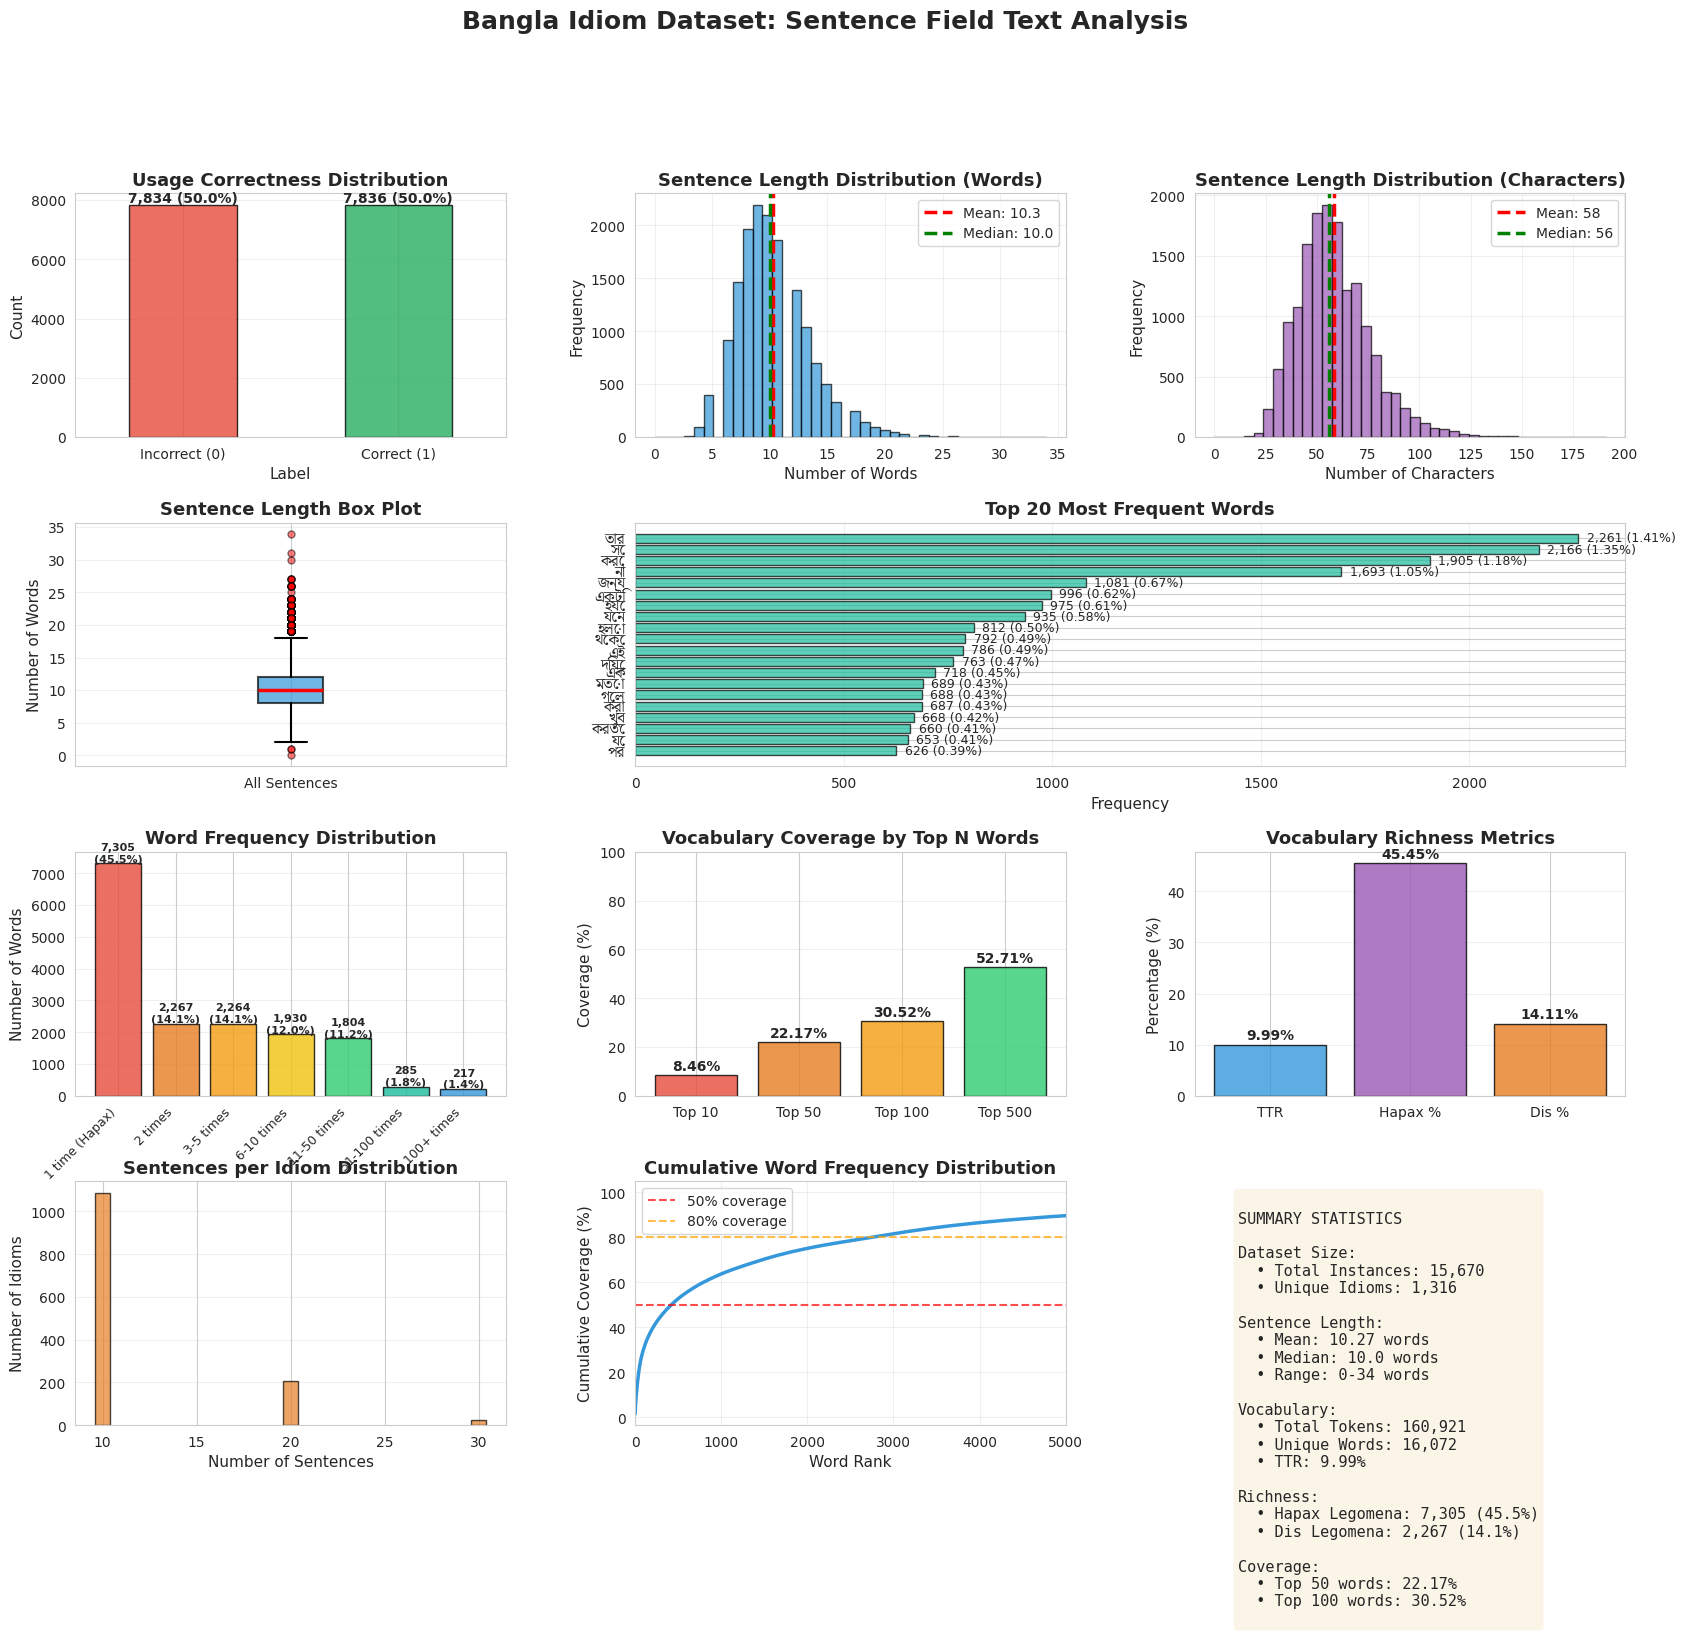

In [ ]:
import matplotlib.font_manager as fm
import requests

font_url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSerifBengali/NotoSerifBengali-Regular.ttf"
font_path = "/content/NotoSerifBengali-Regular.ttf"

response = requests.get(font_url)
with open(font_path, "wb") as f:
    f.write(response.content)

fm.fontManager.addfont(font_path)
bangla_font = fm.FontProperties(fname=font_path)


import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.gridspec import GridSpec

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

INPUT_JSONL = "/content/drive/MyDrive/THESIS/DATASETS/INPUT_DATASET.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/THESIS/DATASET_ANALYSIS"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print("LOADING DATASET")
print("="*60)

data = []
with open(INPUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))

df = pd.DataFrame(data)
print(f"✅ Loaded {len(df)} instances")
print(f"✅ Columns: {list(df.columns)}")

print("\n" + "="*60)
print("BASIC DATASET STATISTICS")
print("="*60)

total_instances = len(df)
unique_idioms = df['idiom_word'].nunique()
avg_sentences_per_idiom = total_instances / unique_idioms

print(f"Total Instances: {total_instances:,}")
print(f"Unique Idioms Covered: {unique_idioms:,}")
print(f"Average Sentences per Idiom: {avg_sentences_per_idiom:.2f}")

if 's_label' in df.columns:
    s_label_dist = df['s_label'].value_counts().sort_index()
    print(f"\nUsage Correctness Label Distribution (s_label):")
    for label, count in s_label_dist.items():
        pct = (count / total_instances) * 100
        label_name = "Correct" if label == 1 else "Incorrect"
        print(f"  {label} ({label_name}): {count:,} instances ({pct:.2f}%)")

idiom_counts = df['idiom_word'].value_counts()
print(f"\nIdiom Distribution:")
print(f"  Min sentences per idiom: {idiom_counts.min()}")
print(f"  Max sentences per idiom: {idiom_counts.max()}")
print(f"  Mean sentences per idiom: {idiom_counts.mean():.2f}")
print(f"  Median sentences per idiom: {idiom_counts.median():.1f}")

print("\n" + "="*60)
print("SENTENCE FIELD: TEXT ANALYSIS")
print("="*60)

df['sentence_word_count'] = df['sentence'].apply(lambda x: len(str(x).split()))

print(f"\n📊 WORD-LEVEL STATISTICS:")
print(f"  Mean length: {df['sentence_word_count'].mean():.2f} words")
print(f"  Median length: {df['sentence_word_count'].median():.1f} words")
print(f"  Std deviation: {df['sentence_word_count'].std():.2f} words")
print(f"  Min length: {df['sentence_word_count'].min()} words")
print(f"  Max length: {df['sentence_word_count'].max()} words")
print(f"  25th percentile: {df['sentence_word_count'].quantile(0.25):.1f} words")
print(f"  75th percentile: {df['sentence_word_count'].quantile(0.75):.1f} words")
print(f"  90th percentile: {df['sentence_word_count'].quantile(0.90):.1f} words")
print(f"  95th percentile: {df['sentence_word_count'].quantile(0.95):.1f} words")

df['sentence_char_count'] = df['sentence'].str.len()

print(f"\n📊 CHARACTER-LEVEL STATISTICS:")
print(f"  Mean length: {df['sentence_char_count'].mean():.2f} characters")
print(f"  Median length: {df['sentence_char_count'].median():.1f} characters")
print(f"  Std deviation: {df['sentence_char_count'].std():.2f} characters")
print(f"  Min length: {df['sentence_char_count'].min()} characters")
print(f"  Max length: {df['sentence_char_count'].max()} characters")

print("\n" + "="*60)
print("SENTENCE FIELD: VOCABULARY RICHNESS")
print("="*60)

all_words = []
for sentence in df['sentence']:
    words = str(sentence).split()
    all_words.extend(words)

unique_vocab = set(all_words)
total_tokens = len(all_words)

print(f"\n📚 VOCABULARY SIZE:")
print(f"  Total tokens (words): {total_tokens:,}")
print(f"  Unique words (types): {len(unique_vocab):,}")

ttr = (len(unique_vocab) / total_tokens) * 100

print(f"\n📈 LEXICAL DIVERSITY:")
print(f"  Type-Token Ratio (TTR): {ttr:.2f}%")
print(f"  Interpretation:")
if ttr > 40:
    print(f"    → High diversity (TTR > 40%) - Rich vocabulary variation")
elif ttr > 30:
    print(f"    → Moderate diversity (30-40%) - Typical for focused domain text")
else:
    print(f"    → Lower diversity (TTR < 30%) - Some repetitive patterns")

word_freq = Counter(all_words)

hapax_words = [word for word, count in word_freq.items() if count == 1]
hapax_count = len(hapax_words)
hapax_pct = (hapax_count / len(unique_vocab)) * 100

print(f"\n📖 HAPAX LEGOMENA (words appearing only once):")
print(f"  Count: {hapax_count:,} words")
print(f"  Percentage of vocabulary: {hapax_pct:.2f}%")
print(f"  Interpretation:")
print(f"    → High hapax (>50%): Very diverse, many rare words")
print(f"    → Moderate hapax (30-50%): Balanced vocabulary")
print(f"    → Low hapax (<30%): More repetitive core vocabulary")

dis_words = [word for word, count in word_freq.items() if count == 2]
dis_count = len(dis_words)
dis_pct = (dis_count / len(unique_vocab)) * 100

print(f"\n📖 DIS LEGOMENA (words appearing exactly twice):")
print(f"  Count: {dis_count:,} words")
print(f"  Percentage of vocabulary: {dis_pct:.2f}%")

freq_bands = {
    "1 time (Hapax)": sum(1 for c in word_freq.values() if c == 1),
    "2 times": sum(1 for c in word_freq.values() if c == 2),
    "3-5 times": sum(1 for c in word_freq.values() if 3 <= c <= 5),
    "6-10 times": sum(1 for c in word_freq.values() if 6 <= c <= 10),
    "11-50 times": sum(1 for c in word_freq.values() if 11 <= c <= 50),
    "51-100 times": sum(1 for c in word_freq.values() if 51 <= c <= 100),
    "100+ times": sum(1 for c in word_freq.values() if c > 100)
}

print(f"\n📊 WORD FREQUENCY DISTRIBUTION:")
for band, count in freq_bands.items():
    pct = (count / len(unique_vocab)) * 100
    print(f"  {band}: {count:,} words ({pct:.2f}%)")

print("\n" + "="*60)
print("SENTENCE FIELD: MOST FREQUENT WORDS")
print("="*60)

top_50 = word_freq.most_common(50)

print(f"\n🔝 TOP 50 MOST FREQUENT WORDS:")
for rank, (word, count) in enumerate(top_50, 1):
    pct = (count / total_tokens) * 100
    print(f"  {rank:2d}. '{word}' → {count:,} occurrences ({pct:.3f}%)")

top_10_coverage = sum(count for _, count in word_freq.most_common(10)) / total_tokens * 100
top_50_coverage = sum(count for _, count in word_freq.most_common(50)) / total_tokens * 100
top_100_coverage = sum(count for _, count in word_freq.most_common(100)) / total_tokens * 100
top_500_coverage = sum(count for _, count in word_freq.most_common(500)) / total_tokens * 100

print(f"\n📊 VOCABULARY COVERAGE:")
print(f"  Top 10 words cover: {top_10_coverage:.2f}% of all tokens")
print(f"  Top 50 words cover: {top_50_coverage:.2f}% of all tokens")
print(f"  Top 100 words cover: {top_100_coverage:.2f}% of all tokens")
print(f"  Top 500 words cover: {top_500_coverage:.2f}% of all tokens")

print("\n" + "="*60)
print("SAVING STATISTICS")
print("="*60)

stats_summary = {
    "dataset_overview": {
        "total_instances": int(total_instances),
        "unique_idioms": int(unique_idioms),
        "avg_sentences_per_idiom": float(avg_sentences_per_idiom)
    },
    "label_distribution": {
        "s_label": {
            int(k): {
                "count": int(v),
                "percentage": float(v / total_instances * 100)
            } for k, v in s_label_dist.items()
        }
    },
    "sentence_text_statistics": {
        "word_level": {
            "mean": float(df['sentence_word_count'].mean()),
            "median": float(df['sentence_word_count'].median()),
            "std": float(df['sentence_word_count'].std()),
            "min": int(df['sentence_word_count'].min()),
            "max": int(df['sentence_word_count'].max()),
            "p25": float(df['sentence_word_count'].quantile(0.25)),
            "p50": float(df['sentence_word_count'].quantile(0.50)),
            "p75": float(df['sentence_word_count'].quantile(0.75)),
            "p90": float(df['sentence_word_count'].quantile(0.90)),
            "p95": float(df['sentence_word_count'].quantile(0.95))
        },
        "character_level": {
            "mean": float(df['sentence_char_count'].mean()),
            "median": float(df['sentence_char_count'].median()),
            "std": float(df['sentence_char_count'].std()),
            "min": int(df['sentence_char_count'].min()),
            "max": int(df['sentence_char_count'].max())
        }
    },
    "vocabulary_richness": {
        "total_tokens": total_tokens,
        "unique_words": len(unique_vocab),
        "type_token_ratio_percentage": float(ttr),
        "hapax_legomena": {
            "count": hapax_count,
            "percentage": float(hapax_pct)
        },
        "dis_legomena": {
            "count": dis_count,
            "percentage": float(dis_pct)
        },
        "frequency_distribution": freq_bands,
        "vocabulary_coverage": {
            "top_10_words": float(top_10_coverage),
            "top_50_words": float(top_50_coverage),
            "top_100_words": float(top_100_coverage),
            "top_500_words": float(top_500_coverage)
        }
    },
    "top_50_words": [
        {
            "rank": i,
            "word": word,
            "count": count,
            "percentage": float(count / total_tokens * 100)
        } for i, (word, count) in enumerate(top_50, 1)
    ]
}

with open(os.path.join(OUTPUT_DIR, "sentence_field_statistics.json"), "w", encoding="utf-8") as f:
    json.dump(stats_summary, f, indent=2, ensure_ascii=False)

print(f"✅ Saved statistics to: {OUTPUT_DIR}/sentence_field_statistics.json")

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
colors_labels = ['#e74c3c', '#27ae60']
s_label_dist.plot(kind='bar', ax=ax1, color=colors_labels, edgecolor='black', alpha=0.8)
ax1.set_title('Usage Correctness Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Label', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_xticklabels(['Incorrect (0)', 'Correct (1)'], rotation=0, fontsize=10)
for i, v in enumerate(s_label_dist):
    pct = v / total_instances * 100
    ax1.text(i, v + 100, f'{v:,} ({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['sentence_word_count'], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(df['sentence_word_count'].mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {df["sentence_word_count"].mean():.1f}')
ax2.axvline(df['sentence_word_count'].median(), color='green', linestyle='--', linewidth=2.5,
            label=f'Median: {df["sentence_word_count"].median():.1f}')
ax2.set_title('Sentence Length Distribution (Words)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Words', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['sentence_char_count'], bins=40, color='#9b59b6', edgecolor='black', alpha=0.7)
ax3.axvline(df['sentence_char_count'].mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {df["sentence_char_count"].mean():.0f}')
ax3.axvline(df['sentence_char_count'].median(), color='green', linestyle='--', linewidth=2.5,
            label=f'Median: {df["sentence_char_count"].median():.0f}')
ax3.set_title('Sentence Length Distribution (Characters)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Number of Characters', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
bp = ax4.boxplot(df['sentence_word_count'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5),
                 medianprops=dict(color='red', linewidth=2.5),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
ax4.set_title('Sentence Length Box Plot', fontsize=13, fontweight='bold')
ax4.set_ylabel('Number of Words', fontsize=11)
ax4.set_xticklabels(['All Sentences'], fontsize=10)
ax4.grid(alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[1, 1:])
top_20 = word_freq.most_common(20)
words_20, counts_20 = zip(*top_20)
y_pos = np.arange(len(words_20))
ax5.barh(y_pos, counts_20, color='#1abc9c', edgecolor='black', alpha=0.7)
ax5.set_yticks(y_pos)

ax5.set_yticklabels(words_20, fontproperties=bangla_font, fontsize=11)

ax5.invert_yaxis()
ax5.set_title('Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
ax5.set_xlabel('Frequency', fontsize=11)
for i, (word, count) in enumerate(top_20):
    pct = count / total_tokens * 100
    ax5.text(count + 20, i, f'{count:,} ({pct:.2f}%)', va='center', fontsize=9)
ax5.grid(alpha=0.3, axis='x')

ax6 = fig.add_subplot(gs[2, 0])
bands_names = list(freq_bands.keys())
bands_values = list(freq_bands.values())
colors_bands = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f', '#2ecc71', '#1abc9c', '#3498db']
ax6.bar(bands_names, bands_values, color=colors_bands, edgecolor='black', alpha=0.8)
ax6.set_title('Word Frequency Distribution', fontsize=13, fontweight='bold')
ax6.set_xlabel('Frequency Band', fontsize=11)
ax6.set_ylabel('Number of Words', fontsize=11)
ax6.set_xticklabels(bands_names, rotation=45, ha='right', fontsize=9)
for i, v in enumerate(bands_values):
    pct = v / len(unique_vocab) * 100
    ax6.text(i, v + 50, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=8, fontweight='bold')
ax6.grid(alpha=0.3, axis='y')

ax7 = fig.add_subplot(gs[2, 1])
coverage_data = {
    'Top 10': top_10_coverage,
    'Top 50': top_50_coverage,
    'Top 100': top_100_coverage,
    'Top 500': top_500_coverage
}
colors_coverage = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71']
ax7.bar(coverage_data.keys(), coverage_data.values(), color=colors_coverage, edgecolor='black', alpha=0.8)
ax7.set_title('Vocabulary Coverage by Top N Words', fontsize=13, fontweight='bold')
ax7.set_ylabel('Coverage (%)', fontsize=11)
ax7.set_ylim(0, 100)
for i, (k, v) in enumerate(coverage_data.items()):
    ax7.text(i, v + 2, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

ax8 = fig.add_subplot(gs[2, 2])
richness_data = {
    'TTR': ttr,
    'Hapax %': hapax_pct,
    'Dis %': dis_pct
}
colors_rich = ['#3498db', '#9b59b6', '#e67e22']
ax8.bar(richness_data.keys(), richness_data.values(), color=colors_rich, edgecolor='black', alpha=0.8)
ax8.set_title('Vocabulary Richness Metrics', fontsize=13, fontweight='bold')
ax8.set_ylabel('Percentage (%)', fontsize=11)
for i, (k, v) in enumerate(richness_data.items()):
    ax8.text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')

ax9 = fig.add_subplot(gs[3, 0])
idiom_freq_bins = idiom_counts.value_counts().sort_index()
ax9.bar(idiom_freq_bins.index, idiom_freq_bins.values, color='#e67e22', edgecolor='black', alpha=0.7)
ax9.set_title('Sentences per Idiom Distribution', fontsize=13, fontweight='bold')
ax9.set_xlabel('Number of Sentences', fontsize=11)
ax9.set_ylabel('Number of Idioms', fontsize=11)
ax9.grid(alpha=0.3, axis='y')

ax10 = fig.add_subplot(gs[3, 1])
sorted_freqs = sorted(word_freq.values(), reverse=True)
cumsum_freqs = np.cumsum(sorted_freqs)
cumsum_pct = (cumsum_freqs / total_tokens) * 100
ax10.plot(range(1, len(cumsum_pct) + 1), cumsum_pct, color='#3498db', linewidth=2.5)
ax10.set_title('Cumulative Word Frequency Distribution', fontsize=13, fontweight='bold')
ax10.set_xlabel('Word Rank', fontsize=11)
ax10.set_ylabel('Cumulative Coverage (%)', fontsize=11)
ax10.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% coverage')
ax10.axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% coverage')
ax10.legend(fontsize=10)
ax10.grid(alpha=0.3)
ax10.set_xlim(0, 5000)

ax11 = fig.add_subplot(gs[3, 2])
ax11.axis('off')
summary_text = f"""
SUMMARY STATISTICS

Dataset Size:
  • Total Instances: {total_instances:,}
  • Unique Idioms: {unique_idioms:,}

Sentence Length:
  • Mean: {df['sentence_word_count'].mean():.2f} words
  • Median: {df['sentence_word_count'].median():.1f} words
  • Range: {df['sentence_word_count'].min()}-{df['sentence_word_count'].max()} words

Vocabulary:
  • Total Tokens: {total_tokens:,}
  • Unique Words: {len(unique_vocab):,}
  • TTR: {ttr:.2f}%

Richness:
  • Hapax Legomena: {hapax_count:,} ({hapax_pct:.1f}%)
  • Dis Legomena: {dis_count:,} ({dis_pct:.1f}%)

Coverage:
  • Top 50 words: {top_50_coverage:.2f}%
  • Top 100 words: {top_100_coverage:.2f}%
"""
ax11.text(0.1, 0.95, summary_text, transform=ax11.transAxes,
          fontsize=11, verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Bangla Idiom Dataset: Sentence Field Text Analysis',
             fontsize=18, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OUTPUT_DIR, "sentence_text_analysis.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved visualization to: {OUTPUT_DIR}/sentence_text_analysis.png")

report_data = {
    'Metric': [
        'Total Instances',
        'Unique Idioms',
        'Correct Usage Count',
        'Incorrect Usage Count',
        'Mean Sentence Length (words)',
        'Median Sentence Length (words)',
        'Std Dev Sentence Length',
        'Min Sentence Length',
        'Max Sentence Length',
        'Mean Character Count',
        'Total Tokens',
        'Unique Words (Vocabulary)',
        'Type-Token Ratio (TTR) %',
        'Hapax Legomena Count',
        'Hapax Percentage %',
        'Dis Legomena Count',
        'Dis Legomena Percentage %',
        'Top 10 Words Coverage %',
        'Top 50 Words Coverage %',
        'Top 100 Words Coverage %'
    ],
    'Value': [
        f'{total_instances:,}',
        f'{unique_idioms:,}',
        f"{s_label_dist.get(1, 0):,} ({s_label_dist.get(1, 0)/total_instances*100:.2f}%)",
        f"{s_label_dist.get(0, 0):,} ({s_label_dist.get(0, 0)/total_instances*100:.2f}%)",
        f'{df["sentence_word_count"].mean():.2f}',
        f'{df["sentence_word_count"].median():.1f}',
        f'{df["sentence_word_count"].std():.2f}',
        f'{df["sentence_word_count"].min()}',
        f'{df["sentence_word_count"].max()}',
        f'{df["sentence_char_count"].mean():.2f}',
        f'{total_tokens:,}',
        f'{len(unique_vocab):,}',
        f'{ttr:.2f}%',
        f'{hapax_count:,}',
        f'{hapax_pct:.2f}%',
        f'{dis_count:,}',
        f'{dis_pct:.2f}%',
        f'{top_10_coverage:.2f}%',
        f'{top_50_coverage:.2f}%',
        f'{top_100_coverage:.2f}%'
    ]
}

report_df = pd.DataFrame(report_data)
report_df.to_csv(os.path.join(OUTPUT_DIR, "sentence_analysis_report.csv"),
                 index=False, encoding='utf-8-sig')
print(f"✅ Saved report to: {OUTPUT_DIR}/sentence_analysis_report.csv")

top_50_df = pd.DataFrame([
    {
        'Rank': i,
        'Word': word,
        'Count': count,
        'Percentage': f'{count/total_tokens*100:.3f}%'
    } for i, (word, count) in enumerate(top_50, 1)
])
top_50_df.to_csv(os.path.join(OUTPUT_DIR, "top_50_words.csv"),
                 index=False, encoding='utf-8-sig')
print(f"✅ Saved top words to: {OUTPUT_DIR}/top_50_words.csv")

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE")
print("="*60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("\nFiles created:")
print("  1. sentence_field_statistics.json - Complete statistics in JSON")
print("  2. sentence_text_analysis.png - Comprehensive visualizations")
print("  3. sentence_analysis_report.csv - Summary table")
print("  4. top_50_words.csv - Top 50 frequent words with stats")

### ✨PREPROCESSING✨

In [ ]:
import os
import json
import unicodedata

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
INPUT_JSONL = "/content/drive/MyDrive/THESIS/DATASETS/INPUT_DATASET.jsonl"

OUT_JSONL = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")
os.makedirs(os.path.dirname(OUT_JSONL), exist_ok=True)

def normalize_bangla(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200c", "")
    text = text.replace("\u200d", "")
    text = " ".join(text.split())
    return text

required_cols = ["sentence", "idiom_word", "idiom_meaning", "s_label"]

n_in = 0
n_out = 0
bad_lines = 0

with open(INPUT_JSONL, "r", encoding="utf-8") as fin, open(OUT_JSONL, "w", encoding="utf-8") as fout:
    for line in fin:
        n_in += 1
        line = line.strip()
        if not line:
            continue

        try:
            obj = json.loads(line)
        except Exception:
            bad_lines += 1
            continue

        for c in required_cols:
            if c not in obj:
                obj[c] = "" if c != "s_label" else 0

        obj["sentence"]      = normalize_bangla(obj["sentence"])
        obj["idiom_word"]    = normalize_bangla(obj["idiom_word"])
        obj["idiom_meaning"] = normalize_bangla(obj["idiom_meaning"])

        try:
            obj["s_label"] = int(obj["s_label"])
        except Exception:
            obj["s_label"] = 0

        fout.write(json.dumps(obj, ensure_ascii=False) + "\n")
        n_out += 1

print("✅ Normalization done")
print("📥 Lines read:", n_in)
print("📤 Lines written:", n_out)
print("⚠️ Bad JSON lines skipped:", bad_lines)
print("📁 Saved:", OUT_JSONL)

✅ Normalization done
📥 Lines read: 15670
📤 Lines written: 15670
⚠️ Bad JSON lines skipped: 0
📁 Saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/01_clean/normalized.jsonl


### ✨ML FEATURE EXTRACTION AND MODEL TRAINING✨

#### FEATURE EXTRACTION

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, save_npz

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RAW_PATH = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")

SPLIT_DIR  = os.path.join(PROJECT_ROOT, "02_splits")
LABELS_DIR = os.path.join(PROJECT_ROOT, "03_labels")

FEAT_ML_THREE  = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")
TEXT_RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")

for d in [SPLIT_DIR, LABELS_DIR, FEAT_ML_THREE, TEXT_RAW_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Loading:", RAW_PATH)
df = pd.read_json(RAW_PATH, lines=True).reset_index(drop=True)

df["sentence"]      = df["sentence"].fillna("").astype(str)
df["idiom_word"]    = df["idiom_word"].fillna("").astype(str)
df["idiom_meaning"] = df["idiom_meaning"].fillna("").astype(str)
df["s_label"]       = df["s_label"].astype(int)

sentences      = df["sentence"].values
idiom_words    = df["idiom_word"].values
idiom_meanings = df["idiom_meaning"].values
labels         = df["s_label"].values

print(f"✅ Samples: {len(df)} | Label dist:", np.bincount(labels))

indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=42)

np.save(os.path.join(SPLIT_DIR, "train_idx.npy"), train_idx)
np.save(os.path.join(SPLIT_DIR, "val_idx.npy"),   val_idx)
np.save(os.path.join(SPLIT_DIR, "test_idx.npy"),  test_idx)

y_train, y_val, y_test = labels[train_idx], labels[val_idx], labels[test_idx]
np.save(os.path.join(LABELS_DIR, "y_train.npy"), y_train)
np.save(os.path.join(LABELS_DIR, "y_val.npy"),   y_val)
np.save(os.path.join(LABELS_DIR, "y_test.npy"),  y_test)

print("✅ Split sizes:", len(train_idx), len(val_idx), len(test_idx))

def save_raw_split(name, idx):
    out_dir = os.path.join(TEXT_RAW_DIR, name)
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "sentence.npy"),      sentences[idx])
    np.save(os.path.join(out_dir, "idiom_word.npy"),    idiom_words[idx])
    np.save(os.path.join(out_dir, "idiom_meaning.npy"), idiom_meanings[idx])

save_raw_split("train", train_idx)
save_raw_split("val",   val_idx)
save_raw_split("test",  test_idx)

print("✅ Saved DL/Transformer raw fields to:", TEXT_RAW_DIR)

X_train_3 = np.column_stack([sentences[train_idx], idiom_words[train_idx], idiom_meanings[train_idx]])
X_val_3   = np.column_stack([sentences[val_idx],   idiom_words[val_idx],   idiom_meanings[val_idx]])
X_test_3  = np.column_stack([sentences[test_idx],  idiom_words[test_idx],  idiom_meanings[test_idx]])

vec_sent = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 6), max_features=5000)
vec_mean = TfidfVectorizer(analyzer="word",   ngram_range=(1, 2), max_features=500)
vec_idm  = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=300)

X_train_sent = vec_sent.fit_transform(X_train_3[:, 0]); X_val_sent = vec_sent.transform(X_val_3[:, 0]); X_test_sent = vec_sent.transform(X_test_3[:, 0])
X_train_mean = vec_mean.fit_transform(X_train_3[:, 2]); X_val_mean = vec_mean.transform(X_val_3[:, 2]); X_test_mean = vec_mean.transform(X_test_3[:, 2])
X_train_idm  = vec_idm.fit_transform(X_train_3[:, 1]);  X_val_idm  = vec_idm.transform(X_val_3[:, 1]);  X_test_idm  = vec_idm.transform(X_test_3[:, 1])

X_train_three_feat = hstack([X_train_sent, X_train_mean, X_train_idm])
X_val_three_feat   = hstack([X_val_sent,   X_val_mean,   X_val_idm])
X_test_three_feat  = hstack([X_test_sent,  X_test_mean,  X_test_idm])

save_npz(os.path.join(FEAT_ML_THREE, "X_train.npz"), X_train_three_feat)
save_npz(os.path.join(FEAT_ML_THREE, "X_val.npz"),   X_val_three_feat)
save_npz(os.path.join(FEAT_ML_THREE, "X_test.npz"),  X_test_three_feat)

with open(os.path.join(FEAT_ML_THREE, "sentence_vectorizer.pkl"), "wb") as f:
    pickle.dump(vec_sent, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(FEAT_ML_THREE, "meaning_vectorizer.pkl"), "wb") as f:
    pickle.dump(vec_mean, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(FEAT_ML_THREE, "idiom_vectorizer.pkl"), "wb") as f:
    pickle.dump(vec_idm,  f, protocol=pickle.HIGHEST_PROTOCOL)

print("✅ ML THREE TF-IDF saved:", X_train_three_feat.shape)

print("\n✅ DONE: Now you can train ML/DL/Transformer models in THREE-FIELDS mode consistently.")
print("🔑 DL/Transformers will load raw fields from:", TEXT_RAW_DIR)

✅ Loading: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/01_clean/normalized.jsonl
✅ Samples: 15670 | Label dist: [7834 7836]
✅ Split sizes: 10969 2350 2351
✅ Saved DL/Transformer raw fields to: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/04_features/text_raw
✅ ML THREE TF-IDF saved: (10969, 5800)

✅ DONE: Now you can train ML/DL/Transformer models in THREE-FIELDS mode consistently.
🔑 DL/Transformers will load raw fields from: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/04_features/text_raw


#### LR

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "LR")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "lr_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "lr_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_lr_elasticnet(C=1.0, l1_ratio=0.2):
    base_lr = LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        l1_ratio=l1_ratio,
        C=C,
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )
    calibrated = CalibratedClassifierCV(base_lr, method="isotonic", cv="prefit")
    return base_lr, calibrated

def run_lr_three(feat_dir, out_dir, C=1.0, l1_ratio=0.2):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    base_lr, calibrated = make_lr_elasticnet(C, l1_ratio)
    base_lr.fit(X_train, y_train)
    calibrated.fit(X_val, y_val)

    tr_prob = base_lr.predict_proba(X_train)[:, 1]
    va_prob = calibrated.predict_proba(X_val)[:, 1]
    te_prob = calibrated.predict_proba(X_test)[:, 1]

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": base_lr.get_params()
    }

    with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(base_lr, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== LR Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_lr_three(FEAT_THREE, OUT_THREE, C=0.8, l1_ratio=0.2)

summary = {
    "LR_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

with open(os.path.join(OUT_THREE, "model.pkl"), "rb") as f:
    saved_model = pickle.load(f)

tr_prob_csv = saved_model.predict_proba(X_train_feat)[:, 1]
va_prob_csv = saved_model.predict_proba(X_val_feat)[:,   1]
te_prob_csv = saved_model.predict_proba(X_test_feat)[:,  1]

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



===== LR Improved (THREE) =====
Best Threshold For Val: 0.49
Fit: GOOD FIT | F1 gap: 0.04
Test F1: 0.83 | Test ROC-AUC: 0.9
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1175
           1       0.78      0.88      0.83      1176

    accuracy                           0.82      2351
   macro avg       0.82      0.82      0.82      2351
weighted avg       0.82      0.82      0.82      2351

✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/lr_three.json
✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/lr_three.png
✅ All 3 split CSVs saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/three/LR


#### SVM

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "SVM")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "svm_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "svm_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_svm_linear_calibrated(C=1.0, max_iter=7000, calibrate_cv=5):
    base = LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=max_iter,
        random_state=42
    )
    calibrated = CalibratedClassifierCV(base, cv=calibrate_cv)
    return calibrated

def run_svm_three(feat_dir, out_dir, C=1.0, max_iter=7000, calibrate_cv=5):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    model = make_svm_linear_calibrated(C=C, max_iter=max_iter, calibrate_cv=calibrate_cv)
    model.fit(X_train, y_train)

    tr_prob = model.predict_proba(X_train)[:, 1]
    va_prob = model.predict_proba(X_val)[:, 1]
    te_prob = model.predict_proba(X_test)[:, 1]

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "C": C,
            "max_iter": max_iter,
            "calibrate_cv": calibrate_cv,
            "class_weight": "balanced",
            "random_state": 42
        }
    }

    with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== SVM Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_svm_three(FEAT_THREE, OUT_THREE, C=0.2, max_iter=7000, calibrate_cv=5)

summary = {
    "SVM_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

with open(os.path.join(OUT_THREE, "model.pkl"), "rb") as f:
    saved_model = pickle.load(f)

tr_prob_csv = saved_model.predict_proba(X_train_feat)[:, 1]
va_prob_csv = saved_model.predict_proba(X_val_feat)[:,   1]
te_prob_csv = saved_model.predict_proba(X_test_feat)[:,  1]

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)


===== SVM Improved (THREE) =====
Best Threshold For Val: 0.35
Fit: GOOD FIT | F1 gap: 0.05
Test F1: 0.84 | Test ROC-AUC: 0.91
              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1175
           1       0.78      0.90      0.84      1176

    accuracy                           0.82      2351
   macro avg       0.83      0.82      0.82      2351
weighted avg       0.83      0.82      0.82      2351

✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/svm_three.json
✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/svm_three.png
✅ All 3 split CSVs saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/three/SVM


#### NB

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "NB")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "nb_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "nb_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_nb_calibrated(alpha=1.0):
    base = MultinomialNB(alpha=alpha)
    calibrated = CalibratedClassifierCV(base, method="isotonic", cv="prefit")
    return base, calibrated

def run_nb_three(feat_dir, out_dir, alpha=1.0):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    base, calibrated = make_nb_calibrated(alpha=alpha)
    base.fit(X_train, y_train)
    calibrated.fit(X_val, y_val)

    tr_prob = base.predict_proba(X_train)[:, 1]
    va_prob = calibrated.predict_proba(X_val)[:, 1]
    te_prob = calibrated.predict_proba(X_test)[:, 1]

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {"alpha": alpha}
    }

    with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(base, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== NB Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_nb_three(FEAT_THREE, OUT_THREE, alpha=1.0)

summary = {
    "NB_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

with open(os.path.join(OUT_THREE, "model.pkl"), "rb") as f:
    saved_model = pickle.load(f)

tr_prob_csv = saved_model.predict_proba(X_train_feat)[:, 1]
va_prob_csv = saved_model.predict_proba(X_val_feat)[:,   1]
te_prob_csv = saved_model.predict_proba(X_test_feat)[:,  1]

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



===== NB Improved (THREE) =====
Best Threshold For Val: 0.43
Fit: GOOD FIT | F1 gap: 0.01
Test F1: 0.79 | Test ROC-AUC: 0.87
              precision    recall  f1-score   support

           0       0.81      0.74      0.77      1175
           1       0.76      0.83      0.79      1176

    accuracy                           0.78      2351
   macro avg       0.79      0.78      0.78      2351
weighted avg       0.79      0.78      0.78      2351

✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/nb_three.json
✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/nb_three.png
✅ All 3 split CSVs saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/three/NB


#### ENSEMBLE

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

MODEL_DIR = os.path.join(PROJECT_ROOT, "06_results", "ml", "three")
OUT_ENSEMBLE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "ENSEMBLE")
os.makedirs(OUT_ENSEMBLE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "ensemble_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "ensemble_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

with open(os.path.join(MODEL_DIR, "LR", "model.pkl"), "rb") as f:
    lr_model = pickle.load(f)

with open(os.path.join(MODEL_DIR, "SVM", "model.pkl"), "rb") as f:
    svm_model = pickle.load(f)

with open(os.path.join(MODEL_DIR, "NB", "model.pkl"), "rb") as f:
    nb_model = pickle.load(f)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def ensemble_weighted_voting(models, X, weights=None):
    """
    Weighted soft voting ensemble
    models: list of (model, name) tuples
    weights: list of weights (default: equal)
    """
    if weights is None:
        weights = [1.0 / len(models)] * len(models)

    weights = np.array(weights)
    weights = weights / weights.sum()

    probas = []
    for model, _ in models:
        prob = model.predict_proba(X)[:, 1]
        probas.append(prob)

    ensemble_prob = np.average(probas, axis=0, weights=weights)
    return ensemble_prob

def run_ensemble_three(feat_dir, out_dir, weights=[0.40, 0.35, 0.25]):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    from sklearn.calibration import CalibratedClassifierCV
    lr_calibrated = CalibratedClassifierCV(lr_model, method="isotonic", cv="prefit")
    lr_calibrated.fit(X_val, y_val)

    nb_calibrated = CalibratedClassifierCV(nb_model, method="isotonic", cv="prefit")
    nb_calibrated.fit(X_val, y_val)

    models = [
        (svm_model, "SVM"),
        (lr_calibrated, "LR"),
        (nb_calibrated, "NB")
    ]

    tr_prob = ensemble_weighted_voting(models, X_train, weights)
    va_prob = ensemble_weighted_voting(models, X_val, weights)
    te_prob = ensemble_weighted_voting(models, X_test, weights)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "ensemble_type": "weighted_voting",
            "weights": {"SVM": weights[0], "LR": weights[1], "NB": weights[2]},
            "models": ["SVM", "LR", "NB"]
        }
    }

    with open(os.path.join(out_dir, "ensemble_config.json"), "w") as f:
        json.dump(payload, f, indent=2)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== ENSEMBLE (THREE) === corrored")
    print(f"Weights: SVM={weights[0]}, LR={weights[1]}, NB={weights[2]}")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_ensemble_three(FEAT_THREE, OUT_ENSEMBLE, weights=[0.40, 0.35, 0.25])

summary = {
    "ENSEMBLE_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"],
        "weights": payload["params"]["weights"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz
from sklearn.calibration import CalibratedClassifierCV

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

lr_cal = CalibratedClassifierCV(lr_model, method="isotonic", cv="prefit")
lr_cal.fit(X_val_feat, y_val)
nb_cal = CalibratedClassifierCV(nb_model, method="isotonic", cv="prefit")
nb_cal.fit(X_val_feat, y_val)

models_ens = [(svm_model, "SVM"), (lr_cal, "LR"), (nb_cal, "NB")]

tr_prob_csv = ensemble_weighted_voting(models_ens, X_train_feat, weights=[0.40, 0.35, 0.25])
va_prob_csv = ensemble_weighted_voting(models_ens, X_val_feat,   weights=[0.40, 0.35, 0.25])
te_prob_csv = ensemble_weighted_voting(models_ens, X_test_feat,  weights=[0.40, 0.35, 0.25])

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_ENSEMBLE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_ENSEMBLE)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



===== ENSEMBLE (THREE) === corrored
Weights: SVM=0.4, LR=0.35, NB=0.25
Best Threshold For Val: 0.46
Fit: GOOD FIT | F1 gap: 0.04
Test F1: 0.83 | Test ROC-AUC: 0.9
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1175
           1       0.80      0.87      0.83      1176

    accuracy                           0.83      2351
   macro avg       0.83      0.83      0.82      2351
weighted avg       0.83      0.83      0.82      2351

✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/ensemble_three.json
✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/ensemble_three.png
✅ All 3 split CSVs saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/three/ENSEMBLE


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


#### COMPARISON ML

In [ ]:
import os
import json
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "06_results", "ml")

OUT_RANKING_CSV = os.path.join(RESULTS_DIR, "model_ranking_three.csv")
OUT_RANKING_JSON = os.path.join(RESULTS_DIR, "model_ranking_three.json")

MODEL_SHORT_NAME = {
    "Logistic Regression": "LR",
    "Support Vector Machine": "SVM",
    "Naive Bayes": "NB",
    "Ensemble (Weighted)": "EnsW"
}

def load_model_metrics(model_name, json_file):
    json_path = os.path.join(RESULTS_DIR, json_file)

    with open(json_path, "r") as f:
        data = json.load(f)

    model_key = list(data.keys())[0]
    metrics = data[model_key]

    folder_map = {
        "LOGISTIC_REGRESSION": "LR",
        "SUPPORT_VECTOR_MACHINE": "SVM",
        "NAIVE_BAYES": "NB",
        "ENSEMBLE_(WEIGHTED)": "ENSEMBLE"
    }

    model_folder = folder_map.get(model_name.replace(" ", "_").upper())

    detailed_path = os.path.join(
        PROJECT_ROOT, "06_results", "ml", "three", model_folder, "metrics.json"
    )

    try:
        with open(detailed_path, "r") as f:
            test_accuracy = json.load(f)["test"]["accuracy"]
    except:
        test_accuracy = None

    return {
        "Model": MODEL_SHORT_NAME[model_name],
        "Test F1": metrics["test_f1"],
        "Test Accuracy": test_accuracy,
        "Val F1": metrics["val_f1"],
        "ROC-AUC": metrics["roc_auc"],
        "Avg Precision": metrics["avg_precision"],
        "Best Threshold": metrics["best_threshold"],
        "F1 Gap": metrics["f1_gap"],
        "Fit Status": metrics["fit_status"]
    }

models_data = []

for name, file in [
    ("Logistic Regression", "lr_three.json"),
    ("Support Vector Machine", "svm_three.json"),
    ("Naive Bayes", "nb_three.json"),
    ("Ensemble (Weighted)", "ensemble_three.json")
]:
    try:
        models_data.append(load_model_metrics(name, file))
    except FileNotFoundError:
        pass

df = pd.DataFrame(models_data)

df = df.sort_values(
    by=["Test F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

df.insert(0, "Rank", range(1, len(df) + 1))

print("\nMODEL RANKING (THREE FEATURES)\n")
print(df.to_string(index=False))

df.to_csv(OUT_RANKING_CSV, index=False)

ranking_json = {
    "feature_set": "THREE",
    "total_models": len(df),
    "best_model": df.iloc[0].to_dict(),
    "rankings": df.to_dict(orient="records")
}

with open(OUT_RANKING_JSON, "w") as f:
    json.dump(ranking_json, f, indent=2)

print("\nFILES SAVED:")
print(f"CSV  → {OUT_RANKING_CSV}")
print(f"JSON → {OUT_RANKING_JSON}")


MODEL RANKING (THREE FEATURES)

 Rank Model  Test F1  Test Accuracy  Val F1  ROC-AUC  Avg Precision  Best Threshold  F1 Gap Fit Status
    1   SVM     0.84           0.82    0.85     0.91           0.91            0.35    0.05   GOOD FIT
    2    LR     0.83           0.82    0.84     0.90           0.88            0.49    0.04   GOOD FIT
    3  EnsW     0.83           0.83    0.84     0.90           0.90            0.46    0.04   GOOD FIT
    4    NB     0.79           0.78    0.81     0.87           0.84            0.43    0.01   GOOD FIT

FILES SAVED:
CSV  → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/model_ranking_three.csv
JSON → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/ml/model_ranking_three.json


### ✨DL FEATURE EXTRACTION AND MODEL TRAINING✨

#### BILSTM

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiLSTM")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "bilstm_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "bilstm_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_bilstm(vocab_size, max_len, emb_dim=128, lstm_units=128, dropout=0.45, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.Bidirectional(layers.LSTM(lstm_units), name="bilstm")(x)
    x = layers.Dropout(dropout, name="dropout1")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(dropout, name="dropout2")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="BiLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_bilstm_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                     emb_dim=128, lstm_units=128, dropout=0.45, lr=2e-4,
                     batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_bilstm(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        lstm_units=lstm_units,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "lstm_units": lstm_units,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== BiLSTM Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_bilstm_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    lstm_units=128,
    dropout=0.45,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "BiLSTM_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

✅ Loaded splits | Train: 10969 | Val: 2350 | Test: 2351
✅ Tokenized | Vocab: 13256 | Shape: (10969, 180)

MODEL ARCHITECTURE


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 180, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense64 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,679,681 (25.48 MB)

 Trainable params: 6,679,681 (25.48 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING START
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 24s 79ms/step - accuracy: 0.6127 - loss: 0.6427 - val_accuracy: 0.7515 - val_loss: 0.5065 - learning_rate: 2.0000e-04
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8422 - loss: 0.3787 - val_accuracy: 0.8234 - val_loss: 0.4227 - learning_rate: 2.0000e-04
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9118 - loss: 0.2368 - val_accuracy: 0.8294 - val_loss: 0.4336 - learning_rate: 2.0000e-04
Epoch 4/15
171/172 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9449 - loss: 0.1728
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.9497 - loss: 0.1557 - val_accuracy: 0.8332 - val_loss: 0.4929 - learning_rate: 2.0000e-04
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9718 - loss: 0.0949 - val_accuracy: 0.8332 - val_loss: 0.5823 - learning_rate: 1.0000e-04
Epoch 5: early stopping
Restoring model we

#### BIGRU

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiGRU")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "bigru_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "bigru_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_bigru(vocab_size, max_len, emb_dim=128, gru_units=128, dropout=0.35, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.Bidirectional(layers.GRU(gru_units), name="bigru")(x)
    x = layers.Dropout(dropout, name="dropout1")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(dropout, name="dropout2")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="BiGRU")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_bigru_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                    emb_dim=128, gru_units=128, dropout=0.35, lr=2e-4,
                    batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_bigru(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        gru_units=gru_units,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "gru_units": gru_units,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== BiGRU Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_bigru_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    gru_units=128,
    dropout=0.35,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "BiGRU_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

✅ Loaded splits | Train: 10969 | Val: 2350 | Test: 2351
✅ Tokenized | Vocab: 13256 | Shape: (10969, 180)

MODEL ARCHITECTURE


Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 180, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru (Bidirectional)           │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense64 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,614,657 (25.23 MB)

 Trainable params: 6,614,657 (25.23 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING START
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4893 - loss: 0.6937 - val_accuracy: 0.4830 - val_loss: 0.6932 - learning_rate: 2.0000e-04
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4867 - loss: 0.6934 - val_accuracy: 0.4945 - val_loss: 0.6933 - learning_rate: 2.0000e-04
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5088 - loss: 0.6928 - val_accuracy: 0.5391 - val_loss: 0.6820 - learning_rate: 2.0000e-04
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7541 - loss: 0.5102 - val_accuracy: 0.8034 - val_loss: 0.4556 - learning_rate: 2.0000e-04
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8914 - loss: 0.2854 - val_accuracy: 0.8243 - val_loss: 0.4354 - learning_rate: 2.0000e-04
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9325 - loss: 0.1936 - val_accuracy: 0.8311 - val_loss: 0.4638 - learning_rate: 2.0000e-04
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s

#### DNN

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "DNN")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "dnn_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "dnn_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_dnn(vocab_size, max_len, emb_dim=128, hidden=(256, 128), dropout=0.40, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.GlobalAveragePooling1D(name="avg_pool")(x)
    x = layers.Dropout(dropout, name="dropout0")(x)

    for i, h in enumerate(hidden):
        x = layers.Dense(h, activation="relu", name=f"dense{i+1}")(x)
        x = layers.Dropout(dropout, name=f"dropout{i+1}")(x)

    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="DNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_dnn_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                  emb_dim=128, hidden=(256, 128), dropout=0.40, lr=2e-4,
                  batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_dnn(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        hidden=hidden,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "hidden": list(hidden),
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== DNN Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_dnn_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    hidden=(256, 128),
    dropout=0.40,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "DNN_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

✅ Loaded splits | Train: 10969 | Val: 2350 | Test: 2351
✅ Tokenized | Vocab: 13256 | Shape: (10969, 180)

MODEL ARCHITECTURE


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 180, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466,049 (24.67 MB)

 Trainable params: 6,466,049 (24.67 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING START
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5105 - loss: 0.6934 - val_accuracy: 0.5013 - val_loss: 0.6929 - learning_rate: 2.0000e-04
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5069 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 2.0000e-04
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5058 - loss: 0.6932 - val_accuracy: 0.5209 - val_loss: 0.6924 - learning_rate: 2.0000e-04
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5090 - loss: 0.6929 - val_accuracy: 0.5694 - val_loss: 0.6922 - learning_rate: 2.0000e-04
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5162 - loss: 0.6921 - val_accuracy: 0.5285 - val_loss: 0.6911 - learning_rate: 2.0000e-04
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5201 - loss: 0.6919 - val_accuracy: 0.5119 - val_loss: 0.6900 - learning_rate: 2.0000e-04
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

#### CNN

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "CNN")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "cnn_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "cnn_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_cnn(vocab_size, max_len, emb_dim=128, filters=128, kernel=5, dropout=0.35, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.Conv1D(filters=filters, kernel_size=kernel, activation="relu", padding="same", name="conv1")(x)
    x = layers.GlobalMaxPooling1D(name="gmp")(x)
    x = layers.Dropout(dropout, name="dropout1")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(dropout, name="dropout2")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="CNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_cnn_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                  emb_dim=128, filters=128, kernel=5, dropout=0.35, lr=2e-4,
                  batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_cnn(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        filters=filters,
        kernel=kernel,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "filters": filters,
            "kernel": kernel,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== CNN Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_cnn_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    filters=128,
    kernel=5,
    dropout=0.35,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "CNN_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

✅ Loaded splits | Train: 10969 | Val: 2350 | Test: 2351
✅ Tokenized | Vocab: 13256 | Shape: (10969, 180)

MODEL ARCHITECTURE


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)          │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 180, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 180, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gmp (GlobalMaxPooling1D)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense64 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,490,369 (24.76 MB)

 Trainable params: 6,490,369 (24.76 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING START
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.5463 - loss: 0.6886 - val_accuracy: 0.7328 - val_loss: 0.6736 - learning_rate: 2.0000e-04
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7345 - loss: 0.6034 - val_accuracy: 0.7791 - val_loss: 0.5017 - learning_rate: 2.0000e-04
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8508 - loss: 0.3861 - val_accuracy: 0.8221 - val_loss: 0.3983 - learning_rate: 2.0000e-04
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9082 - loss: 0.2458 - val_accuracy: 0.8383 - val_loss: 0.3831 - learning_rate: 2.0000e-04
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9447 - loss: 0.1598 - val_accuracy: 0.8421 - val_loss: 0.4021 - learning_rate: 2.0000e-04
Epoch 6/15
167/172 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9646 - loss: 0.1171
Epoch 6: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

#### ENSEMBLE DL

In [ ]:
import os, json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

MODEL_DIRS = {
    "BiGRU": os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiGRU"),
    "CNN": os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "CNN"),
    "BiLSTM": os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiLSTM")
}

OUT_ENSEMBLE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "ENSEMBLE")
os.makedirs(OUT_ENSEMBLE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "ensemble_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "ensemble_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def load_model_and_tokenizer(model_dir):
    """Load keras model and tokenizer from directory"""
    model_path = os.path.join(model_dir, "model.keras")
    tokenizer_path = os.path.join(model_dir, "tokenizer.json")

    model = load_model(model_path)

    with open(tokenizer_path, "r", encoding="utf-8") as f:
        tokenizer = tokenizer_from_json(f.read())

    return model, tokenizer

def prepare_data(tokenizer, texts, max_len=180):
    """Tokenize and pad sequences"""
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

def soft_voting_ensemble(models_dict, tokenizers_dict, X_text, weights=None):
    all_probs = []
    model_names = []

    for name, model in models_dict.items():
        tokenizer = tokenizers_dict[name]
        X = prepare_data(tokenizer, X_text)
        probs = model.predict(X, verbose=0).reshape(-1)
        all_probs.append(probs)
        model_names.append(name)

    all_probs = np.array(all_probs)

    if weights is not None:
        weight_array = np.array([weights[name] for name in model_names])
        weight_array = weight_array / weight_array.sum()
        ensemble_probs = np.average(all_probs, axis=0, weights=weight_array)
        print(f"  ✅ Used weighted average: {dict(zip(model_names, weight_array))}")
    else:
        ensemble_probs = np.mean(all_probs, axis=0)

    return ensemble_probs

def run_ensemble_three(model_dirs, out_dir, weights=None):
    models = {}
    tokenizers = {}

    for name, model_dir in model_dirs.items():
        model, tokenizer = load_model_and_tokenizer(model_dir)
        models[name] = model
        tokenizers[name] = tokenizer

    tr_prob = soft_voting_ensemble(models, tokenizers, X_train_text, weights=weights)

    va_prob = soft_voting_ensemble(models, tokenizers, X_val_text, weights=weights)

    te_prob = soft_voting_ensemble(models, tokenizers, X_test_text, weights=weights)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "ensemble_config": {
            "method": "soft_voting",
            "models": list(model_dirs.keys()),
            "weights": weights if weights else "equal"
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n" + "="*60)
    print("===== ENSEMBLE (BiGRU + CNN + BiLSTM) =====")
    print("="*60)
    print(f"Method: SOFT VOTING")
    print(f"Models: {', '.join(model_dirs.keys())}")
    print(f"Weights: {weights if weights else 'Equal (1/3 each)'}")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload, models, tokenizers

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload, models_global, tokenizers_global = run_ensemble_three(
    MODEL_DIRS,
    OUT_ENSEMBLE,
    weights=None
)

summary = {
    "ENSEMBLE_TOP3_EQUAL": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"],
        "models": payload["ensemble_config"]["models"],
        "weights": "equal"
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("\n✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd

models_csv     = {}
tokenizers_csv = {}

for name, model_dir in MODEL_DIRS.items():
    m, t = load_model_and_tokenizer(model_dir)
    models_csv[name]     = m
    tokenizers_csv[name] = t

thr = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = soft_voting_ensemble(models_csv, tokenizers_csv, X_text, weights=None)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_ENSEMBLE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_ENSEMBLE)


✅ Loaded splits | Train: 10969 | Val: 2350 | Test: 2351

===== ENSEMBLE (BiGRU + CNN + BiLSTM) =====
Method: SOFT VOTING
Models: BiGRU, CNN, BiLSTM
Weights: Equal (1/3 each)
Best Threshold For Val: 0.26
Fit: OVERFITTING | F1 gap: 0.1
Test F1: 0.83 | Test ROC-AUC: 0.91

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.88      0.73      0.79      1175
           1       0.77      0.90      0.83      1176

    accuracy                           0.81      2351
   macro avg       0.82      0.81      0.81      2351
weighted avg       0.82      0.81      0.81      2351


✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/dl/ensemble_three.json
✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/dl/ensemble_three.png
✅ All 3 split CSVs saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/dl/three/ENSEMBLE


#### COMPARISON DL

In [ ]:
import os
import json
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "06_results", "dl")

OUT_RANKING_CSV = os.path.join(RESULTS_DIR, "model_ranking_three.csv")
OUT_RANKING_JSON = os.path.join(RESULTS_DIR, "model_ranking_three.json")

MODEL_SHORT_NAME = {
    "Bidirectional LSTM": "BiLSTM",
    "Bidirectional GRU": "BiGRU",
    "Deep Neural Network": "DNN",
    "Convolutional Neural Network": "CNN",
    "Ensemble (Weighted)": "EnsW"
}

FOLDER_MAP = {
    "BiLSTM": "BiLSTM",
    "BiGRU": "BiGRU",
    "DNN": "DNN",
    "CNN": "CNN",
    "EnsW": "ENSEMBLE"
}

def load_model_metrics(model_name):
    short_name = MODEL_SHORT_NAME[model_name]
    model_folder = FOLDER_MAP[short_name]

    metrics_path = os.path.join(
        PROJECT_ROOT, "06_results", "dl", "three", model_folder, "metrics.json"
    )

    with open(metrics_path, "r") as f:
        m = json.load(f)

    return {
        "Model": short_name,
        "Test F1": m["test"]["f1"],
        "Test Accuracy": m["test"]["accuracy"],
        "Val F1": m["val"]["f1"],
        "ROC-AUC": m["test"]["roc_auc"],
        "Avg Precision": m["test"]["avg_precision"],
        "F1 Gap": m["f1_gap"],
        "Fit Status": m["fit_status"]
    }

models_data = []

for model in MODEL_SHORT_NAME.keys():
    try:
        models_data.append(load_model_metrics(model))
    except FileNotFoundError:
        pass

df = pd.DataFrame(models_data)

df = df.sort_values(
    by=["Test F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

df.insert(0, "Rank", range(1, len(df) + 1))

df = df[
    ["Rank", "Model", "Test F1", "Test Accuracy", "Val F1",
     "ROC-AUC", "Avg Precision", "F1 Gap", "Fit Status"]
]

print("\nMODEL RANKING (DL – THREE FEATURES)\n")
print(df.to_string(index=False))

df.to_csv(OUT_RANKING_CSV, index=False)

ranking_json = {
    "feature_set": "THREE",
    "total_models": len(df),
    "best_model": df.iloc[0].to_dict(),
    "rankings": df.to_dict(orient="records")
}

with open(OUT_RANKING_JSON, "w") as f:
    json.dump(ranking_json, f, indent=2)

print("\nFILES SAVED:")
print(f"CSV  → {OUT_RANKING_CSV}")
print(f"JSON → {OUT_RANKING_JSON}")


MODEL RANKING (DL – THREE FEATURES)

 Rank  Model  Test F1  Test Accuracy  Val F1  ROC-AUC  Avg Precision  F1 Gap  Fit Status
    1    CNN     0.83           0.82    0.84     0.91           0.91    0.12 OVERFITTING
    2   EnsW     0.83           0.81    0.84     0.91           0.91    0.10 OVERFITTING
    3 BiLSTM     0.82           0.82    0.83     0.90           0.90    0.09 OVERFITTING
    4  BiGRU     0.82           0.81    0.83     0.90           0.90    0.10 OVERFITTING
    5    DNN     0.78           0.75    0.80     0.86           0.84    0.08 OVERFITTING

FILES SAVED:
CSV  → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/dl/model_ranking_three.csv
JSON → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/dl/model_ranking_three.json


### ✨TRANSFORMER MODEL TRANING✨

#### BANGLABERT

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
MODEL_NAME = "csebuetnlp/banglabert"

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "banglabert_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "transformers", "banglabert_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

Xtr = build_inputs_three(s_tr, w_tr, m_tr)
Xva = build_inputs_three(s_va, w_va, m_va)
Xte = build_inputs_three(s_te, w_te, m_te)

print(f"✅ Loaded text | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        self.enc = tokenizer(list(texts), truncation=True, padding=False, max_length=max_len)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def metrics_from_logits(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1v  = f1_score(labels, preds, zero_division=0)

    try:
        roc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except Exception:
        roc, ap = None, None

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1v,
        "roc_auc": roc,
        "avg_precision": ap
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def get_predictions(trainer, dataset):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return preds, probs

def run_banglabert_three(raw_dir, out_dir, model_name=MODEL_NAME,
                         max_len=192, epochs=3, batch_size=16, lr=2e-5):

    print("\n" + "="*60)
    print("LOADING TOKENIZER & MODEL")
    print("="*60)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = TxtDataset(Xtr, y_train, tokenizer, max_len)
    val_ds   = TxtDataset(Xva, y_val,   tokenizer, max_len)
    test_ds  = TxtDataset(Xte, y_test,  tokenizer, max_len)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    args = TrainingArguments(
        output_dir=os.path.join(out_dir, "runs"),
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=metrics_from_logits
    )

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    trainer.train()

    model.save_pretrained(os.path.join(out_dir, "model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "tokenizer"))
    print("✅ Saved model & tokenizer")

    print("\n" + "="*60)
    print("GENERATING PREDICTIONS")
    print("="*60)

    tr_pred, tr_prob = get_predictions(trainer, train_ds)
    va_pred, va_prob = get_predictions(trainer, val_ds)
    te_pred, te_prob = get_predictions(trainer, test_ds)

    best_thr = optimize_threshold(y_val, va_prob)

    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    for split_name, y_true, y_pred, y_prob in [
        ("train", y_train, tr_pred, tr_prob),
        ("val", y_val, va_pred, va_prob),
        ("test", y_test, te_pred, te_prob)
    ]:
        df = pd.DataFrame({
            "split": split_name,
            "y_true": y_true,
            "y_pred": y_pred,
            "prob_1": y_prob
        })
        df.to_csv(os.path.join(out_dir, f"predictions_{split_name}.csv"), index=False)

    print("✅ Saved predictions CSVs")

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MODEL_NAME": model_name,
            "max_len": max_len,
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "seed": SEED
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== BanglaBERT Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_banglabert_three(
    RAW_DIR, OUT_THREE,
    model_name=MODEL_NAME,
    max_len=192,
    epochs=3,
    batch_size=16,
    lr=2e-5
)

summary = {
    "BanglaBERT_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

✅ Loaded text | Train: 10969 | Val: 2350 | Test: 2351

LOADING TOKENIZER & MODEL


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...


TRAINING START


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Avg Precision
1,0.299957,0.232343,0.922128,0.892405,0.960000,0.924969,0.982172,0.980423
2,0.117213,0.248601,0.936170,0.945265,0.925957,0.935512,0.983760,0.981076
3,0.050662,0.291974,0.936170,0.924606,0.949787,0.937028,0.983916,0.981225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved model & tokenizer

GENERATING PREDICTIONS


✅ Saved predictions CSVs

===== BanglaBERT Improved (THREE) =====
Best Threshold For Val: 0.84
Fit: GOOD FIT | F1 gap: 0.05
Test F1: 0.95 | Test ROC-AUC: 0.99
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1175
           1       0.94      0.95      0.95      1176

    accuracy                           0.95      2351
   macro avg       0.95      0.95      0.95      2351
weighted avg       0.95      0.95      0.95      2351

✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/banglabert_three.json
✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/banglabert_three.png


#### MBERT

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report,
    confusion_matrix, roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

SEED = 42
MODEL_NAME = "bert-base-multilingual-cased"

MAX_LEN = 192
EPOCHS = 3
BATCH = 16
LR = 2e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "mbert_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "transformers", "mbert_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

Xtr = build_inputs_three(s_tr, w_tr, m_tr)
Xva = build_inputs_three(s_va, w_va, m_va)
Xte = build_inputs_three(s_te, w_te, m_te)

print(f"✅ Loaded text | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        self.enc = tokenizer(list(texts), truncation=True, padding=False, max_length=max_len)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def metrics_from_logits(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1v  = f1_score(labels, preds, zero_division=0)

    try:
        roc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except Exception:
        roc, ap = None, None

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1v,
        "roc_auc": roc,
        "avg_precision": ap
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def get_predictions(trainer, dataset):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return preds, probs

print("\n" + "="*60)
print("LOADING TOKENIZER & MODEL")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TxtDataset(Xtr, y_train, tokenizer, MAX_LEN)
val_ds   = TxtDataset(Xva, y_val,   tokenizer, MAX_LEN)
test_ds  = TxtDataset(Xte, y_test,  tokenizer, MAX_LEN)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=os.path.join(OUT_THREE, "runs"),
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=metrics_from_logits
)

print("\n" + "="*60)
print("TRAINING START")
print("="*60)

trainer.train()

model.save_pretrained(os.path.join(OUT_THREE, "model"))
tokenizer.save_pretrained(os.path.join(OUT_THREE, "tokenizer"))
print("✅ Saved model & tokenizer")

print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

tr_pred, tr_prob = get_predictions(trainer, train_ds)
va_pred, va_prob = get_predictions(trainer, val_ds)
te_pred, te_prob = get_predictions(trainer, test_ds)

best_thr = optimize_threshold(y_val, va_prob)

va_pred = (va_prob >= best_thr["threshold"]).astype(int)
te_pred = (te_prob >= best_thr["threshold"]).astype(int)

train_m = compute_metrics(y_train, tr_pred, tr_prob)
val_m   = compute_metrics(y_val,   va_pred, va_prob)
test_m  = compute_metrics(y_test,  te_pred, te_prob)

status, gap = fit_status(train_m["f1"], val_m["f1"])

for split_name, y_true, y_pred, y_prob in [
    ("train", y_train, tr_pred, tr_prob),
    ("val", y_val, va_pred, va_prob),
    ("test", y_test, te_pred, te_prob)
]:
    df = pd.DataFrame({
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_1": y_prob
    })
    df.to_csv(os.path.join(OUT_THREE, f"predictions_{split_name}.csv"), index=False)

print("✅ Saved predictions CSVs")

payload = {
    "train": train_m,
    "val": val_m,
    "test": test_m,
    "best_threshold": best_thr,
    "fit_status": status,
    "f1_gap": gap,
    "params": {
        "MODEL_NAME": MODEL_NAME,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "batch_size": BATCH,
        "lr": LR,
        "seed": SEED
    }
}

with open(os.path.join(OUT_THREE, "metrics.json"), "w") as f:
    json.dump(payload, f, indent=2)

print("\n===== mBERT Improved (THREE) =====")
print("Best Threshold For Val:", round(best_thr["threshold"], 2))
print("Fit:", status, "| F1 gap:", gap)
print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
print(classification_report(y_test, te_pred, digits=2))

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

artifacts = {
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "tr_pred": tr_pred,
    "va_pred": va_pred,
    "te_pred": te_pred,
    "tr_prob": tr_prob,
    "va_prob": va_prob,
    "te_prob": te_prob
}

save_png_test_cm_and_roc(artifacts, OUT_PNG)

summary = {
    "mBERT_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)

✅ Loaded text | Train: 10969 | Val: 2350 | Test: 2351

LOADING TOKENIZER & MODEL


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...


TRAINING START


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Avg Precision
1,0.414301,0.342128,0.862979,0.833986,0.906383,0.868679,0.936973,0.931909
2,0.266016,0.398923,0.836596,0.905641,0.751489,0.821395,0.937271,0.930954
3,0.182401,0.436031,0.871489,0.874678,0.867234,0.870940,0.941692,0.935990


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved model & tokenizer

GENERATING PREDICTIONS


✅ Saved predictions CSVs

===== mBERT Improved (THREE) =====
Best Threshold For Val: 0.22
Fit: OVERFITTING | F1 gap: 0.09
Test F1: 0.87 | Test ROC-AUC: 0.94
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1175
           1       0.86      0.88      0.87      1176

    accuracy                           0.87      2351
   macro avg       0.87      0.87      0.87      2351
weighted avg       0.87      0.87      0.87      2351

✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/mbert_three.png
✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/mbert_three.json


#### XLMR

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report,
    confusion_matrix, roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

SEED = 42
MODEL_NAME = "xlm-roberta-base"

MAX_LEN = 192
EPOCHS = 3
BATCH = 16
LR = 2e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "xlmr_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "transformers", "xlmr_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

Xtr = build_inputs_three(s_tr, w_tr, m_tr)
Xva = build_inputs_three(s_va, w_va, m_va)
Xte = build_inputs_three(s_te, w_te, m_te)

print(f"✅ Loaded text | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        self.enc = tokenizer(list(texts), truncation=True, padding=False, max_length=max_len)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def metrics_from_logits(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1v  = f1_score(labels, preds, zero_division=0)

    try:
        roc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except Exception:
        roc, ap = None, None

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1v,
        "roc_auc": roc,
        "avg_precision": ap
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def get_predictions(trainer, dataset):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return preds, probs

print("\n" + "="*60)
print("LOADING TOKENIZER & MODEL")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TxtDataset(Xtr, y_train, tokenizer, MAX_LEN)
val_ds   = TxtDataset(Xva, y_val,   tokenizer, MAX_LEN)
test_ds  = TxtDataset(Xte, y_test,  tokenizer, MAX_LEN)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=os.path.join(OUT_THREE, "runs"),
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=metrics_from_logits
)

print("\n" + "="*60)
print("TRAINING START")
print("="*60)

trainer.train()

model.save_pretrained(os.path.join(OUT_THREE, "model"))
tokenizer.save_pretrained(os.path.join(OUT_THREE, "tokenizer"))
print("✅ Saved model & tokenizer")

print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

tr_pred, tr_prob = get_predictions(trainer, train_ds)
va_pred, va_prob = get_predictions(trainer, val_ds)
te_pred, te_prob = get_predictions(trainer, test_ds)

best_thr = optimize_threshold(y_val, va_prob)

va_pred = (va_prob >= best_thr["threshold"]).astype(int)
te_pred = (te_prob >= best_thr["threshold"]).astype(int)

train_m = compute_metrics(y_train, tr_pred, tr_prob)
val_m   = compute_metrics(y_val,   va_pred, va_prob)
test_m  = compute_metrics(y_test,  te_pred, te_prob)

status, gap = fit_status(train_m["f1"], val_m["f1"])

for split_name, y_true, y_pred, y_prob in [
    ("train", y_train, tr_pred, tr_prob),
    ("val", y_val, va_pred, va_prob),
    ("test", y_test, te_pred, te_prob)
]:
    df = pd.DataFrame({
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_1": y_prob
    })
    df.to_csv(os.path.join(OUT_THREE, f"predictions_{split_name}.csv"), index=False)

print("✅ Saved predictions CSVs")

payload = {
    "train": train_m,
    "val": val_m,
    "test": test_m,
    "best_threshold": best_thr,
    "fit_status": status,
    "f1_gap": gap,
    "params": {
        "MODEL_NAME": MODEL_NAME,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "batch_size": BATCH,
        "lr": LR,
        "seed": SEED
    }
}

with open(os.path.join(OUT_THREE, "metrics.json"), "w") as f:
    json.dump(payload, f, indent=2)

print("\n===== XLM-R Improved (THREE) =====")
print("Best Threshold For Val:", round(best_thr["threshold"], 2))
print("Fit:", status, "| F1 gap:", gap)
print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
print(classification_report(y_test, te_pred, digits=2))

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

artifacts = {
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "tr_pred": tr_pred,
    "va_pred": va_pred,
    "te_pred": te_pred,
    "tr_prob": tr_prob,
    "va_prob": va_prob,
    "te_prob": te_prob
}

save_png_test_cm_and_roc(artifacts, OUT_PNG)

summary = {
    "XLMR_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)

✅ Loaded text | Train: 10969 | Val: 2350 | Test: 2351

LOADING TOKENIZER & MODEL


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...


TRAINING START


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Avg Precision
1,0.452795,0.413158,0.837447,0.773637,0.954043,0.854421,0.923532,0.899460
2,0.291381,0.328537,0.863404,0.905123,0.811915,0.855989,0.947857,0.944988
3,0.216325,0.396724,0.878298,0.882201,0.873191,0.877673,0.949399,0.948083


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved model & tokenizer

GENERATING PREDICTIONS


✅ Saved predictions CSVs

===== XLM-R Improved (THREE) =====
Best Threshold For Val: 0.05
Fit: GOOD FIT | F1 gap: 0.06
Test F1: 0.87 | Test ROC-AUC: 0.95
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      1175
           1       0.82      0.93      0.87      1176

    accuracy                           0.87      2351
   macro avg       0.87      0.87      0.87      2351
weighted avg       0.87      0.87      0.87      2351

✅ Saved PNG: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/xlmr_three.png
✅ Saved summary JSON: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/xlmr_three.json


#### COMPARISON TRANSFORMER

In [ ]:
import os
import json
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers")

OUT_RANKING_CSV = os.path.join(RESULTS_DIR, "model_ranking_three.csv")
OUT_RANKING_JSON = os.path.join(RESULTS_DIR, "model_ranking_three.json")

MODEL_SHORT = {
    "BanglaBERT": "BBERT",
    "mBERT": "mBERT",
    "XLM-R": "XLMR"
}

MODEL_FILES = {
    "BanglaBERT": "banglabert_three.json",
    "mBERT": "mbert_three.json",
    "XLM-R": "xlmr_three.json"
}

MODEL_FOLDERS = {
    "BanglaBERT": "BanglaBERT",
    "mBERT": "mBERT",
    "XLM-R": "XLMR"
}

def load_model_metrics(model_name):
    json_path = os.path.join(RESULTS_DIR, MODEL_FILES[model_name])
    with open(json_path, "r") as f:
        data = json.load(f)

    model_key = list(data.keys())[0]
    m = data[model_key]

    detailed_path = os.path.join(
        PROJECT_ROOT, "06_results", "transformers",
        "three", MODEL_FOLDERS[model_name], "metrics.json"
    )

    with open(detailed_path, "r") as f:
        d = json.load(f)

    return {
        "Model": MODEL_SHORT[model_name],
        "Test F1": m["test_f1"],
        "Test Accuracy": d["test"]["accuracy"],
        "Val F1": m["val_f1"],
        "ROC-AUC": m["roc_auc"],
        "Avg Precision": m["avg_precision"],
        "F1 Gap": m["f1_gap"],
        "Fit Status": m["fit_status"]
    }

models_data = []

for model in MODEL_SHORT:
    try:
        models_data.append(load_model_metrics(model))
    except FileNotFoundError:
        pass

df = pd.DataFrame(models_data)

df = df.sort_values(
    by=["Test F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

df.insert(0, "Rank", range(1, len(df) + 1))

df = df[
    ["Rank", "Model", "Test F1", "Test Accuracy",
     "Val F1", "ROC-AUC", "Avg Precision",
     "F1 Gap", "Fit Status"]
]

print("\nTRANSFORMER MODEL RANKING (THREE FEATURES)\n")
print(df.to_string(index=False))

df.to_csv(OUT_RANKING_CSV, index=False)

ranking_json = {
    "feature_set": "THREE",
    "model_type": "TRANSFORMER",
    "total_models": len(df),
    "best_model": df.iloc[0].to_dict(),
    "rankings": df.to_dict(orient="records")
}

with open(OUT_RANKING_JSON, "w") as f:
    json.dump(ranking_json, f, indent=2)

print("\nFILES SAVED:")
print(f"CSV  → {OUT_RANKING_CSV}")
print(f"JSON → {OUT_RANKING_JSON}")


TRANSFORMER MODEL RANKING (THREE FEATURES)

 Rank Model  Test F1  Test Accuracy  Val F1  ROC-AUC  Avg Precision  F1 Gap  Fit Status
    1 BBERT     0.94           0.94    0.94     0.98           0.98    0.05    GOOD FIT
    2  XLMR     0.87           0.87    0.89     0.95           0.95    0.06    GOOD FIT
    3 mBERT     0.87           0.87    0.88     0.94           0.94    0.09 OVERFITTING

FILES SAVED:
CSV  → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/model_ranking_three.csv
JSON → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/model_ranking_three.json


### ✨FINAL COMPARISON TABLE✨

In [ ]:
import os, json
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

ROOTS = {
    "ML":          os.path.join(PROJECT_ROOT, "06_results", "ml"),
    "DL":          os.path.join(PROJECT_ROOT, "06_results", "dl"),
    "HYBRID":      os.path.join(PROJECT_ROOT, "06_results", "hybrid"),
    "TRANSFORMER": os.path.join(PROJECT_ROOT, "06_results", "transformers"),
}

MODELS = {
    "ML":          ["LR", "SVM", "NB", "ENSEMBLE"],
    "DL":          ["BiLSTM", "BiGRU", "DNN", "CNN", "DL_ENSEMBLE"],
    "HYBRID":      ["TFIDF_BiLSTM"],
    "TRANSFORMER": ["BanglaBERT", "mBERT", "XLMR"],
}

MODE = "three"

def safe_get(d, path, default=None):
    cur = d
    for k in path:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

rows = []
for family, root in ROOTS.items():
    for model in MODELS[family]:
        metrics_path = os.path.join(root, MODE, model, "metrics.json")
        if not os.path.exists(metrics_path):
            continue

        with open(metrics_path, "r") as f:
            m = json.load(f)

        rows.append({
            "family": family,
            "mode": "THREE",
            "model": model,

            "fit_status": safe_get(m, ["fit_status"]),
            "f1_gap": safe_get(m, ["f1_gap"]),

            "val_accuracy": safe_get(m, ["val", "accuracy"]),
            "test_accuracy": safe_get(m, ["test", "accuracy"]),

            "val_f1": safe_get(m, ["val", "f1"]),
            "test_f1": safe_get(m, ["test", "f1"]),
            "test_roc_auc": safe_get(m, ["test", "roc_auc"]),
            "test_avg_precision": safe_get(m, ["test", "avg_precision"]),
        })

df = pd.DataFrame(rows)

num_cols = [
    "f1_gap",
    "val_accuracy", "test_accuracy",
    "val_f1", "test_f1",
    "test_roc_auc", "test_avg_precision"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_sorted = df.sort_values(
    by=["test_f1", "test_roc_auc", "test_avg_precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

df_sorted["rank_global"] = np.arange(1, len(df_sorted) + 1)

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_FINAL_GLOBAL = os.path.join(OUT_DIR, "final_global_three_only_comparison.csv")
df_sorted.to_csv(OUT_FINAL_GLOBAL, index=False)

print("✅ Saved GLOBAL final comparison (THREE only):")
print(OUT_FINAL_GLOBAL)

print("\n===== FINAL GLOBAL RANKING (THREE ONLY) =====")
display(df_sorted[
    ["rank_global","family","model","mode",
     "val_accuracy","test_accuracy",
     "val_f1","test_f1","test_roc_auc","test_avg_precision",
     "fit_status","f1_gap"]
])

df_good = df_sorted[df_sorted["fit_status"] == "GOOD FIT"].copy().reset_index(drop=True)
df_good["rank_global_goodfit"] = np.arange(1, len(df_good) + 1)

OUT_FINAL_GLOBAL_GOOD = os.path.join(OUT_DIR, "final_global_three_only_goodfit_only.csv")
df_good.to_csv(OUT_FINAL_GLOBAL_GOOD, index=False)

print("\n✅ Saved GLOBAL GOOD FIT ONLY ranking (THREE only):")
print(OUT_FINAL_GLOBAL_GOOD)

print("\n===== GLOBAL RANKING (ONLY GOOD FIT MODELS) — THREE ONLY =====")
display(df_good[
    ["rank_global_goodfit","family","model","mode",
     "val_accuracy","test_accuracy",
     "val_f1","test_f1","test_roc_auc","test_avg_precision",
     "fit_status","f1_gap"]
])

✅ Saved GLOBAL final comparison (THREE only):
/content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/final_global_three_only_comparison.csv

===== FINAL GLOBAL RANKING (THREE ONLY) =====


,rank_global,family,model,mode,val_accuracy,test_accuracy,val_f1,test_f1,test_roc_auc,test_avg_precision,fit_status,f1_gap
0,1,TRANSFORMER,BanglaBERT,THREE,0.94,0.94,0.94,0.94,0.98,0.98,GOOD FIT,0.05
1,2,TRANSFORMER,XLMR,THREE,0.88,0.87,0.89,0.87,0.95,0.95,GOOD FIT,0.06
2,3,TRANSFORMER,mBERT,THREE,0.88,0.87,0.88,0.87,0.94,0.94,OVERFITTING,0.09
3,4,ML,SVM,THREE,0.83,0.82,0.85,0.84,0.91,0.91,GOOD FIT,0.05
4,5,DL,CNN,THREE,0.83,0.82,0.84,0.83,0.91,0.91,OVERFITTING,0.12
5,6,ML,ENSEMBLE,THREE,0.83,0.83,0.84,0.83,0.90,0.90,GOOD FIT,0.04
6,7,ML,LR,THREE,0.83,0.82,0.84,0.83,0.90,0.88,GOOD FIT,0.04
7,8,DL,DL_ENSEMBLE,THREE,0.84,0.83,0.84,0.83,0.90,0.87,OVERFITTING,0.13
8,9,DL,BiLSTM,THREE,0.82,0.82,0.83,0.82,0.90,0.90,OVERFITTING,0.09
9,10,DL,BiGRU,THREE,0.82,0.81,0.83,0.82,0.90,0.90,OVERFITTING,0.10



✅ Saved GLOBAL GOOD FIT ONLY ranking (THREE only):
/content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/final_global_three_only_goodfit_only.csv

===== GLOBAL RANKING (ONLY GOOD FIT MODELS) — THREE ONLY =====


,rank_global_goodfit,family,model,mode,val_accuracy,test_accuracy,val_f1,test_f1,test_roc_auc,test_avg_precision,fit_status,f1_gap
0,1,TRANSFORMER,BanglaBERT,THREE,0.94,0.94,0.94,0.94,0.98,0.98,GOOD FIT,0.05
1,2,TRANSFORMER,XLMR,THREE,0.88,0.87,0.89,0.87,0.95,0.95,GOOD FIT,0.06
2,3,ML,SVM,THREE,0.83,0.82,0.85,0.84,0.91,0.91,GOOD FIT,0.05
3,4,ML,ENSEMBLE,THREE,0.83,0.83,0.84,0.83,0.90,0.90,GOOD FIT,0.04
4,5,ML,LR,THREE,0.83,0.82,0.84,0.83,0.90,0.88,GOOD FIT,0.04
5,6,ML,NB,THREE,0.80,0.78,0.81,0.79,0.87,0.84,GOOD FIT,0.01


### ✨ 1 STAGE REASONING PIPELINE✨

In [ ]:
import os, json, random
import numpy as np
import torch

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME = "csebuetnlp/banglat5"

MAX_SRC_LEN = 256
MAX_TGT_LEN = 128

EPOCHS_SINGLE = 4
LR = 3e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
DATA_BASE = os.path.join(PROJECT_ROOT, "07_t5_data_reason")

GOLD_DIR = os.path.join(DATA_BASE, "gold")

OUT_BASE   = os.path.join(PROJECT_ROOT, "06_results", "t5_reason")
OUT_SINGLE = os.path.join(OUT_BASE, "single_stage_gold")
os.makedirs(OUT_SINGLE, exist_ok=True)

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

class T5JsonlDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_src_len, max_tgt_len):
        self.rows = rows
        self.tok = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]
        src = str(r["input_text"])
        tgt = str(r["target_text"])

        model_inputs = self.tok(
            src,
            max_length=self.max_src_len,
            truncation=True,
            padding=False
        )

        labels = self.tok(
            text_target=tgt,
            max_length=self.max_tgt_len,
            truncation=True,
            padding=False
        )

        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}

def train_stage(model, tokenizer, train_rows, val_rows, out_dir, epochs, stage_name):
    train_ds = T5JsonlDataset(train_rows, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)
    val_ds   = T5JsonlDataset(val_rows,   tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)

    args = Seq2SeqTrainingArguments(
        output_dir=os.path.join(out_dir, "runs"),
        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,

        num_train_epochs=epochs,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        learning_rate=LR,

        predict_with_generate=True,
        logging_steps=50,
        seed=SEED,
        report_to="none"
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
    )

    trainer.train()

    train_eval = trainer.evaluate(train_ds)
    val_eval   = trainer.evaluate(val_ds)

    model.save_pretrained(os.path.join(out_dir, "model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "tokenizer"))

    payload = {
        "stage": stage_name,
        "epochs": epochs,
        "MODEL_NAME": MODEL_NAME,
        "train_eval": {k: float(v) for k, v in train_eval.items()},
        "val_eval":   {k: float(v) for k, v in val_eval.items()},
        "MAX_SRC_LEN": MAX_SRC_LEN,
        "MAX_TGT_LEN": MAX_TGT_LEN,
        "BATCH": BATCH,
        "LR": LR
    }
    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print(f"✅ Saved {stage_name} to {out_dir}")
    return model

g_train = read_jsonl(os.path.join(GOLD_DIR, "train.jsonl"))
g_val   = read_jsonl(os.path.join(GOLD_DIR, "val.jsonl"))

print(f"Gold train: {len(g_train)} | Gold val: {len(g_val)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model = train_stage(model, tokenizer, g_train, g_val, OUT_SINGLE, EPOCHS_SINGLE, "single_stage_gold")

print("\n✅ Single-stage training complete")
print("Saved to:", OUT_SINGLE)

import pandas as pd
import matplotlib.pyplot as plt

TEST_JSONL       = os.path.join(GOLD_DIR, "test.jsonl")
OUT_TEST_CSV     = os.path.join(OUT_SINGLE, "test_generations.csv")
OUT_TEST_METRICS = os.path.join(OUT_SINGLE, "test_eval_metrics.json")
OUT_TEST_PNG     = os.path.join(OUT_SINGLE, "test_eval_plots.png")

def _tok_words(s: str):
    return str(s).strip().split()

def _lcs_len(a, b):
    n, m = len(a), len(b)
    dp = [0] * (m + 1)
    for i in range(1, n + 1):
        prev = 0
        for j in range(1, m + 1):
            tmp = dp[j]
            if a[i - 1] == b[j - 1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = tmp
    return dp[m]

def rouge_l_f1(ref: str, hyp: str):
    r = _tok_words(ref)
    h = _tok_words(hyp)
    if len(r) == 0 or len(h) == 0:
        return 0.0
    lcs = _lcs_len(r, h)
    prec = lcs / max(len(h), 1)
    rec  = lcs / max(len(r), 1)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def _ngram_counts(tokens, n):
    counts = {}
    for i in range(len(tokens) - n + 1):
        ng = tuple(tokens[i:i+n])
        counts[ng] = counts.get(ng, 0) + 1
    return counts

def bleu4(ref: str, hyp: str, smooth=1.0):
    r = _tok_words(ref)
    h = _tok_words(hyp)
    if len(h) == 0:
        return 0.0
    precisions = []
    for n in [1, 2, 3, 4]:
        ref_c = _ngram_counts(r, n)
        hyp_c = _ngram_counts(h, n)
        overlap = 0
        total   = 0
        for ng, c in hyp_c.items():
            total   += c
            overlap += min(c, ref_c.get(ng, 0))
        p = (overlap + smooth) / (total + smooth)
        precisions.append(p)
    ref_len = len(r)
    hyp_len = len(h)
    if hyp_len == 0:
        bp = 0.0
    elif hyp_len > ref_len:
        bp = 1.0
    else:
        bp = np.exp(1 - ref_len / max(hyp_len, 1))
    return float(bp * np.exp(np.mean(np.log(precisions))))

def generate_batch(model, tokenizer, texts, max_src_len=MAX_SRC_LEN, max_new_tokens=MAX_TGT_LEN, batch_size=16):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                max_length=max_src_len,
                truncation=True,
                padding=True,
                return_tensors="pt"
            ).to(device)
            gen = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True
            )
            dec = tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs.extend([d.strip() for d in dec])
    return outs

t_rows      = read_jsonl(TEST_JSONL)
test_inputs = [r["input_text"]  for r in t_rows]
test_refs   = [r["target_text"] for r in t_rows]

eval_tokenizer = AutoTokenizer.from_pretrained(os.path.join(OUT_SINGLE, "tokenizer"))
eval_model     = AutoModelForSeq2SeqLM.from_pretrained(os.path.join(OUT_SINGLE, "model"))

test_hyps = generate_batch(eval_model, eval_tokenizer, test_inputs, batch_size=16)

rouges   = [rouge_l_f1(ref, hyp) for ref, hyp in zip(test_refs, test_hyps)]
bleus    = [bleu4(ref, hyp)      for ref, hyp in zip(test_refs, test_hyps)]
gen_lens = [len(_tok_words(h)) for h in test_hyps]
ref_lens = [len(_tok_words(r)) for r in test_refs]

df_out = pd.DataFrame({
    "id":             [r.get("id", f"test_{i}") for i, r in enumerate(t_rows)],
    "input_text":     test_inputs,
    "target_text":    test_refs,
    "generated_text": test_hyps,
    "rougeL_f1":      rouges,
    "bleu4":          bleus,
    "gen_len_tokens": gen_lens,
    "ref_len_tokens": ref_lens
})
df_out.to_csv(OUT_TEST_CSV, index=False)

metrics_payload = {
    "model":                "single_stage_gold",
    "num_samples":          int(len(t_rows)),
    "rougeL_f1_mean":      float(np.mean(rouges))   if rouges   else None,
    "rougeL_f1_median":    float(np.median(rouges)) if rouges   else None,
    "bleu4_mean":          float(np.mean(bleus))    if bleus    else None,
    "bleu4_median":        float(np.median(bleus))  if bleus    else None,
    "gen_len_mean_tokens": float(np.mean(gen_lens)) if gen_lens else None,
    "ref_len_mean_tokens": float(np.mean(ref_lens)) if ref_lens else None,
}
with open(OUT_TEST_METRICS, "w") as f:
    json.dump(metrics_payload, f, indent=2)

print("\n✅ Saved generations:", OUT_TEST_CSV)
print("✅ Saved metrics:",     OUT_TEST_METRICS)
print("\nMETRICS SUMMARY:")
for k, v in metrics_payload.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 4))
plt.hist(rouges, bins=30)
plt.title("ROUGE-L F1 distribution (Test) — single-stage gold")
plt.xlabel("ROUGE-L F1")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_TEST_PNG, dpi=200)
plt.close()

print("\n✅ Saved plot:", OUT_TEST_PNG)

Gold train: 10969 | Gold val: 2350


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.n

Epoch,Training Loss,Validation Loss
1,3.330486,2.688187
2,2.529159,1.920816
3,2.242342,1.682071
4,2.174735,1.605124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved single_stage_gold to /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/single_stage_gold

✅ Single-stage training complete
Saved to: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/single_stage_gold


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



✅ Saved generations: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/single_stage_gold/test_generations.csv
✅ Saved metrics: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/single_stage_gold/test_eval_metrics.json

METRICS SUMMARY:
model: single_stage_gold
num_samples: 2351
rougeL_f1_mean: 0.3722654206911077
rougeL_f1_median: 0.4166666666666667
bleu4_mean: 0.19804191447945899
bleu4_median: 0.15367394061536743
gen_len_mean_tokens: 9.449170565716717
ref_len_mean_tokens: 17.317311782220333

✅ Saved plot: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/single_stage_gold/test_eval_plots.png


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM
)
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

BB_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "model")
BB_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "tokenizer")

T5_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "model")
T5_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "tokenizer")

RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
GOLD_DIR  = os.path.join(PROJECT_ROOT, "07_t5_data_reason", "gold")

OUT_BASE = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "condition_c")
os.makedirs(OUT_BASE, exist_ok=True)

OUT_TEST_CSV     = os.path.join(OUT_BASE, "test_generations.csv")
OUT_TEST_METRICS = os.path.join(OUT_BASE, "test_eval_metrics.json")
OUT_TEST_PNG     = os.path.join(OUT_BASE, "test_eval_plots.png")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

print("\n⏳ Loading BanglaBERT classifier...")
bb_tokenizer = AutoTokenizer.from_pretrained(BB_TOKENIZER_DIR)
bb_model     = AutoModelForSequenceClassification.from_pretrained(BB_MODEL_DIR).to(device)
bb_model.eval()
print("✅ BanglaBERT loaded.")

print("\n⏳ Loading BanglaT5 reason generator...")
eval_tokenizer = AutoTokenizer.from_pretrained(T5_TOKENIZER_DIR)
eval_model     = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_DIR).to(device)
eval_model.eval()
print("✅ BanglaT5 loaded.")

s_te = np.load(os.path.join(RAW_DIR, "test", "sentence.npy"),      allow_pickle=True).astype(str)
w_te = np.load(os.path.join(RAW_DIR, "test", "idiom_word.npy"),    allow_pickle=True).astype(str)
m_te = np.load(os.path.join(RAW_DIR, "test", "idiom_meaning.npy"), allow_pickle=True).astype(str)
y_te = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

t_rows    = []
with open(os.path.join(GOLD_DIR, "test.jsonl"), "r", encoding="utf-8") as f:
    for line in f:
        t_rows.append(json.loads(line))

test_refs = [r["target_text"] for r in t_rows]

print(f"\n✅ Test samples     : {len(s_te)}")
print(f"✅ Gold refs loaded : {len(test_refs)}")
assert len(s_te) == len(test_refs), "Mismatch between raw text and gold JSONL test size!"

def build_classifier_input(sentence, idiom_word, idiom_meaning):
    return f"বাগধারা: {idiom_word} । অর্থ: {idiom_meaning} । বাক্য: {sentence}"

def banglabert_predict_batch(sentences, idiom_words, idiom_meanings, batch_size=32):
    all_preds = []
    all_probs = []
    texts = [
        build_classifier_input(s, w, m)
        for s, w, m in zip(sentences, idiom_words, idiom_meanings)
    ]
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = bb_tokenizer(
            batch_texts,
            max_length=192,
            truncation=True,
            padding=True,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = bb_model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())
    return np.array(all_preds), np.array(all_probs)

print("\n⏳ Step 1: BanglaBERT classifying test set...")
bb_preds, bb_probs = banglabert_predict_batch(s_te, w_te, m_te)

bb_acc = accuracy_score(y_te, bb_preds)
bb_f1  = f1_score(y_te, bb_preds, zero_division=0)
print(f"✅ BanglaBERT done | Accuracy: {bb_acc:.4f} | F1: {bb_f1:.4f}")
print(classification_report(y_te, bb_preds, zero_division=0))

def make_input(sentence, idiom_word, idiom_meaning, predicted_label):
    base = f"বাগধারা: {idiom_word} । অর্থ: {idiom_meaning} । বাক্য: {sentence}"
    return f"{base}\nলেবেল (s_label): {int(predicted_label)}\nকারণ লিখুন:"

test_inputs = [
    make_input(s, w, m, pred)
    for s, w, m, pred in zip(s_te, w_te, m_te, bb_preds)
]

MAX_SRC_LEN = 256
MAX_TGT_LEN = 128

def generate_batch(model, tokenizer, texts, max_src_len=MAX_SRC_LEN, max_new_tokens=MAX_TGT_LEN, batch_size=16):
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                max_length=max_src_len,
                truncation=True,
                padding=True,
                return_tensors="pt"
            ).to(device)
            gen = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3
            )
            dec = tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs.extend([d.strip() for d in dec])
    return outs

print("\n⏳ Step 2: BanglaT5 generating reasons...")
test_hyps = generate_batch(eval_model, eval_tokenizer, test_inputs, batch_size=16)
print("✅ Generation complete.")

def _tok_words(s):
    return str(s).strip().split()

def _lcs_len(a, b):
    n, m = len(a), len(b)
    dp = [0] * (m + 1)
    for i in range(1, n + 1):
        prev = 0
        for j in range(1, m + 1):
            tmp = dp[j]
            if a[i-1] == b[j-1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j-1])
            prev = tmp
    return dp[m]

def rouge_l_f1(ref, hyp):
    r, h = _tok_words(ref), _tok_words(hyp)
    if not r or not h:
        return 0.0
    lcs  = _lcs_len(r, h)
    prec = lcs / max(len(h), 1)
    rec  = lcs / max(len(r), 1)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def _ngram_counts(tokens, n):
    counts = {}
    for i in range(len(tokens) - n + 1):
        ng = tuple(tokens[i:i+n])
        counts[ng] = counts.get(ng, 0) + 1
    return counts

def bleu4(ref, hyp, smooth=1.0):
    r, h = _tok_words(ref), _tok_words(hyp)
    if not h:
        return 0.0
    precisions = []
    for n in [1, 2, 3, 4]:
        rc = _ngram_counts(r, n)
        hc = _ngram_counts(h, n)
        overlap = sum(min(c, rc.get(ng, 0)) for ng, c in hc.items())
        total   = sum(hc.values())
        precisions.append((overlap + smooth) / (total + smooth))
    bp = 1.0 if len(h) > len(r) else np.exp(1 - len(r) / max(len(h), 1))
    return float(bp * np.exp(np.mean(np.log(precisions))))

rouges   = [rouge_l_f1(ref, hyp) for ref, hyp in zip(test_refs, test_hyps)]
bleus    = [bleu4(ref, hyp)      for ref, hyp in zip(test_refs, test_hyps)]
gen_lens = [len(_tok_words(h)) for h in test_hyps]
ref_lens = [len(_tok_words(r)) for r in test_refs]

df_out = pd.DataFrame({
    "id":             [r.get("id", f"test_{i}") for i, r in enumerate(t_rows)],
    "input_text":     test_inputs,
    "target_text":    test_refs,
    "generated_text": test_hyps,
    "gold_label":     y_te,
    "banglabert_pred": bb_preds,
    "banglabert_prob": bb_probs,
    "rougeL_f1":      rouges,
    "bleu4":          bleus,
    "gen_len_tokens": gen_lens,
    "ref_len_tokens": ref_lens,
})
df_out.to_csv(OUT_TEST_CSV, index=False)

metrics_payload = {
    "num_samples":          int(len(t_rows)),
    "rougeL_f1_mean":       float(np.mean(rouges))     if rouges   else None,
    "rougeL_f1_median":     float(np.median(rouges))   if rouges   else None,
    "bleu4_mean":           float(np.mean(bleus))      if bleus    else None,
    "bleu4_median":         float(np.median(bleus))    if bleus    else None,
    "gen_len_mean_tokens":  float(np.mean(gen_lens))   if gen_lens else None,
    "ref_len_mean_tokens":  float(np.mean(ref_lens))   if ref_lens else None,
}

with open(OUT_TEST_METRICS, "w") as f:
    json.dump(metrics_payload, f, indent=2)

print("\n✅ Saved generations:", OUT_TEST_CSV)
print("✅ Saved metrics:",     OUT_TEST_METRICS)
print("\nMETRICS SUMMARY:")
for k, v in metrics_payload.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 4))
plt.hist(rouges, bins=30)
plt.title("ROUGE-L F1 distribution (Test) — Condition C: BanglaBERT → BanglaT5")
plt.xlabel("ROUGE-L F1")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_TEST_PNG, dpi=200)
plt.close()

print("\n✅ Saved plot:", OUT_TEST_PNG)
print("\n✅ CONDITION C COMPLETE")

Device: cuda

⏳ Loading BanglaBERT classifier...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BanglaBERT loaded.

⏳ Loading BanglaT5 reason generator...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ BanglaT5 loaded.

✅ Test samples     : 2351
✅ Gold refs loaded : 2351

⏳ Step 1: BanglaBERT classifying test set...
✅ BanglaBERT done | Accuracy: 0.9413 | F1: 0.9420
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1175
           1       0.93      0.95      0.94      1176

    accuracy                           0.94      2351
   macro avg       0.94      0.94      0.94      2351
weighted avg       0.94      0.94      0.94      2351


⏳ Step 2: BanglaT5 generating reasons...
✅ Generation complete.

✅ Saved generations: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/condition_c/test_generations.csv
✅ Saved metrics: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/condition_c/test_eval_metrics.json

METRICS SUMMARY:
num_samples: 2351
rougeL_f1_mean: 0.8655677980114073
rougeL_f1_median: 0.8846153846153846
bleu4_mean: 0.7723468277169698
bleu4_median: 0.7546930988815487
gen_len_mean_tokens: 17.334

### ✨ 2 STAGE REASONING PIPELINE✨

In [ ]:
import os, json
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

DATA_PATH = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")

SPLIT_DIR = os.path.join(PROJECT_ROOT, "02_splits")

TEACHER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")

OUT_BASE = os.path.join(PROJECT_ROOT, "07_t5_data_reason")
OUT_GOLD = os.path.join(OUT_BASE, "gold")
OUT_PSEU = os.path.join(OUT_BASE, "banglabert_pred")
os.makedirs(OUT_GOLD, exist_ok=True)
os.makedirs(OUT_PSEU, exist_ok=True)

T5_INPUT_MODE = "three"

def combine_three(sentence, idiom_word, idiom_meaning):
    return f"বাগধারা: {idiom_word} । অর্থ: {idiom_meaning} । বাক্য: {sentence}"

def make_input(mode, row, label_value):
    if mode == "single":
        base = f"বাক্য: {row['sentence']}"
    else:
        base = combine_three(row["sentence"], row["idiom_word"], row["idiom_meaning"])
    return f"{base}\nলেবেল (s_label): {int(label_value)}\nকারণ লিখুন:"

def write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

rows = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

train_idx = np.load(os.path.join(SPLIT_DIR, "train_idx.npy"))
val_idx   = np.load(os.path.join(SPLIT_DIR, "val_idx.npy"))
test_idx  = np.load(os.path.join(SPLIT_DIR, "test_idx.npy"))

split_map = {"train": train_idx, "val": val_idx, "test": test_idx}

for split, idxs in split_map.items():
    pred_df = pd.read_csv(os.path.join(TEACHER_DIR, f"predictions_{split}.csv"))

    gold_records = []
    pseudo_records = []

    for j, dataset_i in enumerate(idxs):
        r = rows[int(dataset_i)]

        gold_label = int(r["s_label"])
        reason_txt = str(r["reason"]).strip()

        pseudo_label = int(pred_df.loc[j, "y_pred"])
        pseudo_prob  = float(pred_df.loc[j, "prob_1"])

        gold_records.append({
            "id": f"{split}_{j}",
            "input_text": make_input(T5_INPUT_MODE, r, gold_label),
            "target_text": reason_txt,
            "s_label": gold_label,
            "label_source": "gold",
        })

        pseudo_records.append({
            "id": f"{split}_{j}",
            "input_text": make_input(T5_INPUT_MODE, r, pseudo_label),
            "target_text": reason_txt,
            "s_label": pseudo_label,
            "label_source": "banglabert_pred",
            "teacher_prob_1": pseudo_prob
        })

    write_jsonl(os.path.join(OUT_GOLD, f"{split}.jsonl"), gold_records)
    write_jsonl(os.path.join(OUT_PSEU, f"{split}.jsonl"), pseudo_records)

print("✅ Done building T5 reasoning datasets")
print("Gold:", OUT_GOLD)
print("Pseudo:", OUT_PSEU)
print("Teacher preds from:", TEACHER_DIR)
print("T5 input mode:", T5_INPUT_MODE)

✅ Done building T5 reasoning datasets
Gold: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/07_t5_data_reason/gold
Pseudo: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/07_t5_data_reason/banglabert_pred
Teacher preds from: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/three/BanglaBERT
T5 input mode: three


In [ ]:
import os, json, random
import numpy as np
import torch

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME = "csebuetnlp/banglat5"

MAX_SRC_LEN = 256
MAX_TGT_LEN = 128

EPOCHS_STAGE1 = 2   # pseudo
EPOCHS_STAGE2 = 2   # gold
BATCH = 8
LR = 3e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
DATA_BASE = os.path.join(PROJECT_ROOT, "07_t5_data_reason")

PSEU_DIR = os.path.join(DATA_BASE, "banglabert_pred")
GOLD_DIR = os.path.join(DATA_BASE, "gold")

OUT_BASE = os.path.join(PROJECT_ROOT, "06_results", "t5_reason")
OUT_PSEU = os.path.join(OUT_BASE, "stage1_pseudo")
OUT_GOLD = os.path.join(OUT_BASE, "stage2_gold")
os.makedirs(OUT_PSEU, exist_ok=True)
os.makedirs(OUT_GOLD, exist_ok=True)

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

class T5JsonlDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_src_len, max_tgt_len):
        self.rows = rows
        self.tok = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]
        src = str(r["input_text"])
        tgt = str(r["target_text"])

        model_inputs = self.tok(src, max_length=self.max_src_len, truncation=True, padding=False)
        with self.tok.as_target_tokenizer():
            labels = self.tok(tgt, max_length=self.max_tgt_len, truncation=True, padding=False)

        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}

def train_stage(model, tokenizer, train_rows, val_rows, out_dir, epochs, stage_name):
    train_ds = T5JsonlDataset(train_rows, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)
    val_ds   = T5JsonlDataset(val_rows,   tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)

    args = Seq2SeqTrainingArguments(
        output_dir=os.path.join(out_dir, "runs"),
        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,

        num_train_epochs=epochs,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        learning_rate=LR,

        predict_with_generate=True,
        logging_steps=50,
        seed=SEED,
        report_to="none"
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
    )

    trainer.train()

    train_eval = trainer.evaluate(train_ds)
    val_eval   = trainer.evaluate(val_ds)

    model.save_pretrained(os.path.join(out_dir, "model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "tokenizer"))

    payload = {
        "stage": stage_name,
        "epochs": epochs,
        "MODEL_NAME": MODEL_NAME,
        "train_eval": {k: float(v) for k, v in train_eval.items()},
        "val_eval":   {k: float(v) for k, v in val_eval.items()},
        "MAX_SRC_LEN": MAX_SRC_LEN,
        "MAX_TGT_LEN": MAX_TGT_LEN,
        "BATCH": BATCH,
        "LR": LR
    }
    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print(f"✅ Saved {stage_name} to {out_dir}")
    return model

p_train = read_jsonl(os.path.join(PSEU_DIR, "train.jsonl"))
p_val   = read_jsonl(os.path.join(PSEU_DIR, "val.jsonl"))
g_train = read_jsonl(os.path.join(GOLD_DIR, "train.jsonl"))
g_val   = read_jsonl(os.path.join(GOLD_DIR, "val.jsonl"))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model = train_stage(model, tokenizer, p_train, p_val, OUT_PSEU, EPOCHS_STAGE1, "stage1_pseudo")

model = train_stage(model, tokenizer, g_train, g_val, OUT_GOLD, EPOCHS_STAGE2, "stage2_gold")

print("\n✅ Dual training complete")
print("Stage1 (pseudo):", OUT_PSEU)
print("Stage2 (gold):  ", OUT_GOLD)

import pandas as pd
import matplotlib.pyplot as plt

TEST_JSONL = os.path.join(GOLD_DIR, "test.jsonl")
OUT_TEST_CSV = os.path.join(OUT_GOLD, "test_generations.csv")
OUT_TEST_METRICS = os.path.join(OUT_GOLD, "test_eval_metrics.json")
OUT_TEST_PNG = os.path.join(OUT_GOLD, "test_eval_plots.png")

def _tok_words(s: str):
    return str(s).strip().split()

def _lcs_len(a, b):
    n, m = len(a), len(b)
    dp = [0] * (m + 1)
    for i in range(1, n + 1):
        prev = 0
        for j in range(1, m + 1):
            tmp = dp[j]
            if a[i - 1] == b[j - 1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = tmp
    return dp[m]

def rouge_l_f1(ref: str, hyp: str):
    r = _tok_words(ref)
    h = _tok_words(hyp)
    if len(r) == 0 or len(h) == 0:
        return 0.0
    lcs = _lcs_len(r, h)
    prec = lcs / max(len(h), 1)
    rec = lcs / max(len(r), 1)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def _ngram_counts(tokens, n):
    counts = {}
    for i in range(len(tokens) - n + 1):
        ng = tuple(tokens[i:i+n])
        counts[ng] = counts.get(ng, 0) + 1
    return counts

def bleu4(ref: str, hyp: str, smooth=1.0):
    r = _tok_words(ref)
    h = _tok_words(hyp)
    if len(h) == 0:
        return 0.0

    precisions = []
    for n in [1,2,3,4]:
        ref_c = _ngram_counts(r, n)
        hyp_c = _ngram_counts(h, n)
        overlap = 0
        total = 0
        for ng, c in hyp_c.items():
            total += c
            overlap += min(c, ref_c.get(ng, 0))
        p = (overlap + smooth) / (total + smooth)
        precisions.append(p)

    ref_len = len(r)
    hyp_len = len(h)
    if hyp_len == 0:
        bp = 0.0
    elif hyp_len > ref_len:
        bp = 1.0
    else:
        bp = np.exp(1 - ref_len / max(hyp_len, 1))

    score = bp * np.exp(np.mean(np.log(precisions)))
    return float(score)

def generate_batch(model, tokenizer, texts, max_src_len=MAX_SRC_LEN, max_new_tokens=MAX_TGT_LEN, batch_size=16):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                max_length=max_src_len,
                truncation=True,
                padding=True,
                return_tensors="pt"
            ).to(device)

            gen = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True
            )
            dec = tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs.extend([d.strip() for d in dec])
    return outs

t_rows = read_jsonl(TEST_JSONL)
test_inputs = [r["input_text"] for r in t_rows]
test_refs   = [r["target_text"] for r in t_rows]

eval_tokenizer = AutoTokenizer.from_pretrained(os.path.join(OUT_GOLD, "tokenizer"))
eval_model = AutoModelForSeq2SeqLM.from_pretrained(os.path.join(OUT_GOLD, "model"))

test_hyps = generate_batch(eval_model, eval_tokenizer, test_inputs, batch_size=16)

rouges = [rouge_l_f1(ref, hyp) for ref, hyp in zip(test_refs, test_hyps)]
bleus  = [bleu4(ref, hyp) for ref, hyp in zip(test_refs, test_hyps)]
gen_lens = [len(_tok_words(h)) for h in test_hyps]
ref_lens = [len(_tok_words(r)) for r in test_refs]

df_out = pd.DataFrame({
    "id": [r.get("id", f"test_{i}") for i, r in enumerate(t_rows)],
    "input_text": test_inputs,
    "target_text": test_refs,
    "generated_text": test_hyps,
    "rougeL_f1": rouges,
    "bleu4": bleus,
    "gen_len_tokens": gen_lens,
    "ref_len_tokens": ref_lens
})
df_out.to_csv(OUT_TEST_CSV, index=False)

metrics_payload = {
    "num_samples": int(len(t_rows)),
    "rougeL_f1_mean": float(np.mean(rouges)) if len(rouges) else None,
    "rougeL_f1_median": float(np.median(rouges)) if len(rouges) else None,
    "bleu4_mean": float(np.mean(bleus)) if len(bleus) else None,
    "bleu4_median": float(np.median(bleus)) if len(bleus) else None,
    "gen_len_mean_tokens": float(np.mean(gen_lens)) if len(gen_lens) else None,
    "ref_len_mean_tokens": float(np.mean(ref_lens)) if len(ref_lens) else None,
}
with open(OUT_TEST_METRICS, "w") as f:
    json.dump(metrics_payload, f, indent=2)

print("\n✅ Saved generations:", OUT_TEST_CSV)
print("✅ Saved metrics:", OUT_TEST_METRICS)
print("\nMETRICS SUMMARY:")
for k, v in metrics_payload.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 4))
plt.hist(rouges, bins=30)
plt.title("ROUGE-L F1 distribution (Test)")
plt.xlabel("ROUGE-L F1")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_TEST_PNG, dpi=200)
plt.close()

print("\n✅ Saved plot:", OUT_TEST_PNG)

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


...

Epoch,Training Loss,Validation Loss
1,0.809700,0.450922
2,0.734600,0.409673


✅ Saved stage1_pseudo to /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage1_pseudo


/tmp/ipython-input-635056630.py:89: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4174: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.523100,0.346233
2,0.567400,0.334447


✅ Saved stage2_gold to /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold

✅ Dual training complete
Stage1 (pseudo): /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage1_pseudo
Stage2 (gold):   /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold

✅ Saved generations: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/test_generations.csv
✅ Saved metrics: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/test_eval_metrics.json

METRICS SUMMARY:
num_samples: 2351
rougeL_f1_mean: 0.9036605583171314
rougeL_f1_median: 0.9230769230769231
bleu4_mean: 0.8196802616346881
bleu4_median: 0.803154665668484
gen_len_mean_tokens: 16.86176095278605
ref_len_mean_tokens: 17.317311782220333

✅ Saved plot: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/test_eval_plots.png


In [ ]:
import os, json
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
MODEL_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "model")
TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "tokenizer")

TEST_JSONL = os.path.join(PROJECT_ROOT, "07_t5_data_reason", "gold", "test.jsonl")

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, "test_generations.csv")
OUT_METRICS = os.path.join(OUT_DIR, "test_eval_metrics.json")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR).to(device)
model.eval()

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

def lcs_length(a, b):
    n, m = len(a), len(b)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n):
        ai = a[i]
        for j in range(m):
            if ai == b[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    return dp[n][m]

def rouge_l_f1(ref, hyp):
    ref_t = ref.strip().split()
    hyp_t = hyp.strip().split()
    if len(ref_t) == 0 or len(hyp_t) == 0:
        return 0.0
    lcs = lcs_length(ref_t, hyp_t)
    prec = lcs / (len(hyp_t) + 1e-12)
    rec  = lcs / (len(ref_t) + 1e-12)
    if prec + rec == 0:
        return 0.0
    return float(2 * prec * rec / (prec + rec + 1e-12))

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def bleu4(ref, hyp, max_n=4):
    ref_t = ref.strip().split()
    hyp_t = hyp.strip().split()
    if len(hyp_t) == 0:
        return 0.0

    weights = [0.25]*max_n
    p_ns = []

    for n in range(1, max_n+1):
        ref_ngr = ngrams(ref_t, n)
        hyp_ngr = ngrams(hyp_t, n)
        if len(hyp_ngr) == 0:
            p_ns.append(0.0)
            continue

        ref_counts = {}
        for ng in ref_ngr:
            ref_counts[ng] = ref_counts.get(ng, 0) + 1

        match = 0
        hyp_counts = {}
        for ng in hyp_ngr:
            hyp_counts[ng] = hyp_counts.get(ng, 0) + 1

        for ng, c in hyp_counts.items():
            match += min(c, ref_counts.get(ng, 0))

        p_ns.append(match / (len(hyp_ngr) + 1e-12))

    ref_len = len(ref_t)
    hyp_len = len(hyp_t)
    bp = 1.0 if hyp_len > ref_len else np.exp(1 - (ref_len / (hyp_len + 1e-12)))

    smooth_p = [max(p, 1e-12) for p in p_ns]
    score = bp * np.exp(sum(w*np.log(p) for w, p in zip(weights, smooth_p)))
    return float(score)

def generate_batch(texts, max_new_tokens=96, num_beams=4):
    enc = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return tokenizer.batch_decode(out, skip_special_tokens=True)

data = read_jsonl(TEST_JSONL)

BATCH_SIZE = 8
all_rows = []
rouges = []
bleus = []

for i in range(0, len(data), BATCH_SIZE):
    batch = data[i:i+BATCH_SIZE]
    inputs = [x["input_text"] for x in batch]
    refs   = [x["target_text"] for x in batch]

    hyps = generate_batch(inputs, max_new_tokens=96, num_beams=4)

    for j, (inp, ref, hyp) in enumerate(zip(inputs, refs, hyps)):
        r = rouge_l_f1(ref, hyp)
        b = bleu4(ref, hyp)
        rouges.append(r)
        bleus.append(b)
        all_rows.append({
            "id": batch[j].get("id", f"test_{i+j}"),
            "rougeL_f1": r,
            "bleu4": b,
            "target_text": ref,
            "generated_text": hyp
        })

df = pd.DataFrame(all_rows)
df.to_csv(OUT_CSV, index=False)

metrics = {
    "num_samples": int(len(df)),
    "rougeL_f1_mean": float(np.mean(rouges)) if rouges else 0.0,
    "rougeL_f1_median": float(np.median(rouges)) if rouges else 0.0,
    "bleu4_mean": float(np.mean(bleus)) if bleus else 0.0,
    "bleu4_median": float(np.median(bleus)) if bleus else 0.0,
    "gen_len_mean_tokens": float(np.mean([len(t.split()) for t in df["generated_text"].tolist()])) if len(df) else 0.0,
    "ref_len_mean_tokens": float(np.mean([len(t.split()) for t in df["target_text"].tolist()])) if len(df) else 0.0
}

with open(OUT_METRICS, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("✅ Saved generations:", OUT_CSV)
print("✅ Saved metrics:", OUT_METRICS)
print("\nMETRICS SUMMARY:")
for k, v in metrics.items():
    print(f"{k}: {v}")

import matplotlib.pyplot as plt

OUT_PNG = os.path.join(OUT_DIR, "test_eval_plots.png")

df["gen_len_tokens"] = df["generated_text"].astype(str).apply(lambda x: len(x.split()))
df["ref_len_tokens"] = df["target_text"].astype(str).apply(lambda x: len(x.split()))

worst = df.sort_values("rougeL_f1", ascending=True).head(20).copy()

fig = plt.figure(figsize=(18, 12))
ax1 = fig.add_subplot(2, 2, 1)
ax1.hist(df["rougeL_f1"].values, bins=30)
ax1.set_title("ROUGE-L F1 distribution (Test)")
ax1.set_xlabel("ROUGE-L F1")
ax1.set_ylabel("Count")

ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(df["bleu4"].values, bins=30)
ax2.set_title("BLEU-4 distribution (Test)")
ax2.set_xlabel("BLEU-4")
ax2.set_ylabel("Count")

ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(df["ref_len_tokens"].values, df["gen_len_tokens"].values, s=10)
ax3.set_title("Generated length vs Reference length (tokens)")
ax3.set_xlabel("Reference length")
ax3.set_ylabel("Generated length")

ax4 = fig.add_subplot(2, 2, 4)
ax4.bar(range(len(worst)), worst["rougeL_f1"].values)
ax4.set_title("Worst 20 samples by ROUGE-L F1")
ax4.set_xlabel("Sample rank (worst → better)")
ax4.set_ylabel("ROUGE-L F1")

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=200)
plt.close(fig)

print("✅ Saved plots:", OUT_PNG)

✅ Saved generations: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/test_generations.csv
✅ Saved metrics: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/test_eval_metrics.json

METRICS SUMMARY:
num_samples: 2351
rougeL_f1_mean: 0.9032578434544535
rougeL_f1_median: 0.923076923076352
bleu4_mean: 0.8089927016843401
bleu4_median: 0.7912619863720177
gen_len_mean_tokens: 16.828158230540197
ref_len_mean_tokens: 17.317311782220333
✅ Saved plots: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/test_eval_plots.png


In [ ]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
MODEL_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "model")
TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "tokenizer")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR).to(device)
model.eval()

def generate_reason(input_text, max_new_tokens=96, num_beams=4):
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return tokenizer.decode(out_ids[0], skip_special_tokens=True)

example_input = """মার চাকরি চলে যাওয়ায় পরিবার অথৈ জলে পড়েছে
লেবেল (s_label): 1
কারণ লিখুন:"""

print("INPUT:\n", example_input)
print("\nGENERATED REASON:\n", generate_reason(example_input))

INPUT:
 মার চাকরি চলে যাওয়ায় পরিবার অথৈ জলে পড়েছে
লেবেল (s_label): 1
কারণ লিখুন:

GENERATED REASON:
 উক্ত 'মার চাকরি চলে যাওয়ায় পরিবার অথৈ জলে পড়েছে' এবং এটি সঠিকভাবে ব্যবহৃত হয়েছে।


### ✨EXAMPLE✨

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/three/BanglaBERT/model"
TOKENIZER_DIR = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/three/BanglaBERT/tokenizer"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()

examples = [
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "অফিসের মহিলাটি খুব গভীর জলের মাছ",
        "true_label": 1,
        "reason": "সঠিক বাগধারাগত ব্যবহার"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "রুপা রাজনীতিতে গভীর জলের মাছ",
        "true_label": 1,
        "reason": "সঠিক বাগধারাগত ব্যবহার"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "নতুন প্রতিবেশী আসলে গভীর জলের মাছ",
        "true_label": 1,
        "reason": "সঠিক বাগধারাগত ব্যবহার"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "রুজি চুপচাপ কিন্তু গভীর জলের মাছ",
        "true_label": 1,
        "reason": "সঠিক বাগধারাগত ব্যবহার"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "ব্যবসায় টিকে থাকতে গভীর জলের মাছ হতে হয়",
        "true_label": 1,
        "reason": "সঠিক বাগধারাগত ব্যবহার"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "পুকুরে গভীর জলের মাছ আছে",
        "true_label": 0,
        "reason": "আক্ষরিক অর্থে মাছ বোঝানো হয়েছে"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "গভীর জলের মাছ ধরার জন্য আমি বড়শি কিনেছি",
        "true_label": 0,
        "reason": "আক্ষরিক অর্থে মাছ ধরা বোঝানো হয়েছে"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "আমি গভীর জলের মাছ ধরতে পারিনি",
        "true_label": 0,
        "reason": "আক্ষরিক ব্যবহার"
    },
    {
        "idiom_word": "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence": "মা বলেন গভীর জলের মাছ খাওয়া ভালো",
        "true_label": 0,
        "reason": "খাদ্য হিসেবে মাছ বোঝানো হয়েছে"
    }
]

def build_input(ex):
    return f"বাগধারা: {ex['idiom_word']} । অর্থ: {ex['idiom_meaning']} । বাক্য: {ex['sentence']}"

print("\n" + "="*80)
print("BANGLABERT QUALITATIVE IDIOM USAGE TEST (ALL EXAMPLES)")
print("="*80)

correct = 0

for i, ex in enumerate(examples, 1):
    text = build_input(ex)

    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=192
    )

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_label = int(probs[1] >= 0.5)
    confidence = probs[1]

    is_correct = pred_label == ex["true_label"]
    correct += int(is_correct)

    print(f"\nExample {i}")
    print(f"Sentence   : {ex['sentence']}")
    print(f"Prediction : {pred_label} | Prob(1) = {confidence:.3f}")
    print(f"GT Label   : {ex['true_label']}")
    print(f"Result     : {'✅ CORRECT' if is_correct else '❌ WRONG'}")
    print(f"Note       : {ex['reason']}")

print("\n" + "-"*80)
print(f"Correct Predictions: {correct}/{len(examples)}")
print(f"Accuracy (Qualitative Set): {correct/len(examples):.2f}")
print("-"*80)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BANGLABERT QUALITATIVE IDIOM USAGE TEST (ALL EXAMPLES)

Example 1
Sentence   : অফিসের মহিলাটি খুব গভীর জলের মাছ
Prediction : 1 | Prob(1) = 0.998
GT Label   : 1
Result     : ✅ CORRECT
Note       : সঠিক বাগধারাগত ব্যবহার

Example 2
Sentence   : রুপা রাজনীতিতে গভীর জলের মাছ
Prediction : 1 | Prob(1) = 0.998
GT Label   : 1
Result     : ✅ CORRECT
Note       : সঠিক বাগধারাগত ব্যবহার

Example 3
Sentence   : নতুন প্রতিবেশী আসলে গভীর জলের মাছ
Prediction : 1 | Prob(1) = 0.998
GT Label   : 1
Result     : ✅ CORRECT
Note       : সঠিক বাগধারাগত ব্যবহার

Example 4
Sentence   : রুজি চুপচাপ কিন্তু গভীর জলের মাছ
Prediction : 0 | Prob(1) = 0.009
GT Label   : 1
Result     : ❌ WRONG
Note       : সঠিক বাগধারাগত ব্যবহার

Example 5
Sentence   : ব্যবসায় টিকে থাকতে গভীর জলের মাছ হতে হয়
Prediction : 1 | Prob(1) = 0.998
GT Label   : 1
Result     : ✅ CORRECT
Note       : সঠিক বাগধারাগত ব্যবহার

Example 6
Sentence   : পুকুরে গভীর জলের মাছ আছে
Prediction : 0 | Prob(1) = 0.001
GT Label   : 0
Result     : ✅ CORRECT


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/three/BanglaBERT/model"
TOKENIZER_DIR = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/three/BanglaBERT/tokenizer"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()

examples_unseen = [
    # Correct idiom usage
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "রাজনীতিতে জয়ী হতে হলে গভীর জলের মাছ হতে হয়", "true_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "নতুন ব্যবসায়ী সত্যিই গভীর জলের মাছ", "true_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "সে চুপচাপভাবে সব পরিস্থিতি দেখলো, সত্যিই গভীর জলের মাছ", "true_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পরীক্ষায় উত্তীর্ণ হতে গভীর জলের মাছ হওয়া জরুরি", "true_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "নেতৃত্বের অবস্থায় সে একজন গভীর জলের মাছ", "true_label": 1},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "কর্মী ছাঁটাই করে সামান্য বোনাস দেওয়া গরু মেরে জুতো দান", "true_label": 1},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "বন্ধুর ক্ষতি করে পরে পুরনো শার্ট দেওয়া গরু মেরে জুতো দান", "true_label": 1},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "নদী দূষণ করে পরে ছোট চারাগাছ লাগানো গরু মেরে জুতো দান", "true_label": 1},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "আমার টাকা চুরি করে এখন চা খাওয়াতে চাওয়া গরু মেরে জুতো দান", "true_label": 1},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "ফসল নষ্ট করে সামান্য সাহায্য করাই গরু মেরে জুতো দান", "true_label": 1},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "আলতাফ আর শরীফের মধ্যে গলায় গলায় ভাব", "true_label": 1},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "স্কুলের সেই পুরোনো বন্ধুগুলোর আজও গলায় গলায় ভাব", "true_label": 1},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "রাজনীতিতে প্রতিদ্বন্দ্বী হলেও, ব্যক্তিগত জীবনে তাদের মধ্যে গলায় গলায় ভাব", "true_label": 1},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "বহু বছর পর দেখা হলেও রবিন আর শোভনের মধ্যে এমন গলায় গলায় ভাব", "true_label": 1},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "দুই বৌয়ের মধ্যে এমন গলায় গলায় ভাব দেখে সবাই অবাক হয়", "true_label": 1},

    # Incorrect literal usage
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "আমি পুকুরে গভীর জলের মাছ ধরতে গেলাম", "true_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "মাছ বাজারে বিক্রি করতে গভীর জলের মাছ কিনেছি", "true_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পুকুরে মাছ না থাকায় গভীর জলের মাছ ধরতে পারিনি", "true_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "রেস্তোরায় মা বললেন গভীর জলের মাছ খাওয়া সুস্বাদু", "true_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পুকুরের পানি পরিষ্কার করতে গভীর জলের মাছ বের করেছি", "true_label": 0},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "দু’টোই ভালো কাজ, তাই এটি গরু মেরে জুতো দান নয়", "true_label": 0},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "বড় সম্পত্তি পেয়ে ছোট দান করাকে গরু মেরে জুতো দান বলা ঠিক নয়", "true_label": 0},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "বড় লোকসানের পর বড় অঙ্কের টাকা দেওয়া গরু মেরে জুতো দান নয়", "true_label": 0},
    {"idiom_word": "গরu মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "ভালো উপহার দেওয়া গরু মেরে জুতো দান নয়", "true_label": 0},
    {"idiom_word": "গরু মেরে জুতো দান", "idiom_meaning": "বড় ক্ষতি করে সামান্য পূরণ",
     "sentence": "বিপদে বড় সাহায্য করাকে গরু মেরে জুতো দান বলা যায় না", "true_label": 0},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "শিক্ষক এবং ছাত্রের মধ্যে গলায় গলায় ভাব থাকা উচিত", "true_label": 0},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "দাদা ছেলের মধ্যে গলায় গলায় ভাব দেখে সবাই খুশি হয়", "true_label": 0},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "দীপায়নের সঙ্গে ফারহান গলায় গলায় ভাব, তাই আমি তাকে ঘৃণা করি", "true_label": 0},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "তাদের মধ্যে খুব ঝগড়া হয়, তাই তাদের গলায় গলায় ভাব", "true_label": 0},
    {"idiom_word": "গলায় গলায় ভাব", "idiom_meaning": "অত্যন্ত গভীর বন্ধুত্ব",
     "sentence": "বসের সঙ্গে কর্মীর গলায় গলায় ভাব, কারণ বস তাকে চাকরি থেকে বরখাস্ত করেছে", "true_label": 0}
]

def build_input(ex):
    return f"বাগধারা: {ex['idiom_word']} । অর্থ: {ex['idiom_meaning']} । বাক্য: {ex['sentence']}"

print("\n" + "="*80)
print("BANGLABERT UNSEEN QUALITATIVE IDIOM TEST (30 EXAMPLES)")
print("="*80)

correct = 0

for i, ex in enumerate(examples_unseen, 1):
    text = build_input(ex)

    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=192
    )

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_label = int(probs[1] >= 0.5)
    confidence = probs[1]

    is_correct = pred_label == ex["true_label"]
    correct += int(is_correct)

    print(f"\nExample {i}")
    print(f"Sentence   : {ex['sentence']}")
    print(f"Prediction : {pred_label} | Prob(1) = {confidence:.3f}")
    print(f"GT Label   : {ex['true_label']} {'| CORRECT ✅ ' if is_correct else '| WRONG ❌'}")

print("\n" + "-"*80)
print(f"Correct Predictions: {correct}/{len(examples_unseen)}")
print(f"Accuracy (Unseen Qualitative Set): {correct/len(examples_unseen):.2f}")
print("-"*80)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BANGLABERT UNSEEN QUALITATIVE IDIOM TEST (30 EXAMPLES)

Example 1
Sentence   : রাজনীতিতে জয়ী হতে হলে গভীর জলের মাছ হতে হয়
Prediction : 1 | Prob(1) = 0.997
GT Label   : 1 | CORRECT ✅ 

Example 2
Sentence   : নতুন ব্যবসায়ী সত্যিই গভীর জলের মাছ
Prediction : 1 | Prob(1) = 0.998
GT Label   : 1 | CORRECT ✅ 

Example 3
Sentence   : সে চুপচাপভাবে সব পরিস্থিতি দেখলো, সত্যিই গভীর জলের মাছ
Prediction : 1 | Prob(1) = 0.997
GT Label   : 1 | CORRECT ✅ 

Example 4
Sentence   : পরীক্ষায় উত্তীর্ণ হতে গভীর জলের মাছ হওয়া জরুরি
Prediction : 0 | Prob(1) = 0.002
GT Label   : 1 | WRONG ❌

Example 5
Sentence   : নেতৃত্বের অবস্থায় সে একজন গভীর জলের মাছ
Prediction : 1 | Prob(1) = 0.998
GT Label   : 1 | CORRECT ✅ 

Example 6
Sentence   : কর্মী ছাঁটাই করে সামান্য বোনাস দেওয়া গরু মেরে জুতো দান
Prediction : 1 | Prob(1) = 0.999
GT Label   : 1 | CORRECT ✅ 

Example 7
Sentence   : বন্ধুর ক্ষতি করে পরে পুরনো শার্ট দেওয়া গরু মেরে জুতো দান
Prediction : 1 | Prob(1) = 0.999
GT Label   : 1 | CORRECT ✅ 

Example 8
S

In [ ]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
MODEL_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "model")
TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "tokenizer")

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_DIR).to(device)
model.eval()

def generate_reason(input_text, max_new_tokens=96, num_beams=4):
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return tokenizer.decode(out_ids[0], skip_special_tokens=True)

examples_seen = [
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "অফিসের মহিলাটি খুব গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "রুপা রাজনীতিতে গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "নতুন প্রতিবেশী আসলে গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "রুজি চুপচাপ কিন্তু গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "ব্যবসায় টিকে থাকতে গভীর জলের মাছ হতে হয়", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পুকুরে গভীর জলের মাছ আছে", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "গভীর জলের মাছ ধরার জন্য আমি বড়শি কিনেছি", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "আমি গভীর জলের মাছ ধরতে পারিনি", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "মা বলেন গভীর জলের মাছ খাওয়া ভালো", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পুকুরের পানি পরিষ্কার করতে গভীর জলের মাছ বের করেছি", "s_label": 0},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "চাকরির আশা দিয়ে শেষে সে অস্বীকার করল, একেই বলে গাছে তুলে মই কাড়া", "s_label": 1},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "হৃষভের মিথ্যা আশ্বাসে ভরসা করে আমি বিনিয়োগ করেছিলাম, সে তো আমাকে গাছে তুলে মই কাড়ল", "s_label": 1},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "বিপদের সময় সাহায্য করব বলে আশ্বাস দিয়েছিল, কিন্তু পরে ফোন ধরল না সে তো গাছে তুলে মই কাড়ল", "s_label": 1},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "নিজের স্বার্থ মিটে যাওয়ার পর সে বন্ধুটিকে একা ফেলে চলে গেল, ঠিক যেমন গাছে তুলে মই কাড়া হয়", "s_label": 1},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "বাড়ি তৈরির জন্য টাকা দেওয়ার কথা বলে এখন সে হাত গুটিয়ে নিয়েছে, যেন গাছে তুলে মই কাড়া", "s_label": 1},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "তিনি শুধু সাহায্য করেই ক্ষান্ত হননি, আমাকে গাছে তুলে মই কাড়ার পর আরও উপরে ওঠার সিঁড়িও দিলেন", "s_label": 0},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "বিপদের সময় সে আমার পাশে ছিল, কিন্তু তার ব্যবহার দেখে মনে হলো যেন গাছে তুলে মই কাড়া", "s_label": 0},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "গাছে তুলে মই কাড়ার ফলস্বরূপ সে আজ তার নিজের উদ্যোগে সফল হয়েছে", "s_label": 0},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "প্রতিশ্রুতি অনুযায়ী সে সময়মতো টাকা দিয়েছিল, তবুও লোকে বলল, সে গাছে তুলে মই কাড়ে", "s_label": 0},
    {"idiom_word": "গাছে তুলে মই কাড়া", "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
     "sentence": "আকাশ থেকে চাঁদ এনে দেওয়ার প্রতিশ্রুতি দিয়ে গাছে তুলে মই কাড়ার কী দরকার?", "s_label": 0},

    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "রাজনীতিতে জয়ী হতে হলে গভীর জলের মাছ হতে হয়", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "নতুন ব্যবসায়ী সত্যিই গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "সে চুপচাপভাবে সব পরিস্থিতি দেখলো, সত্যিই গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পরীক্ষায় উত্তীর্ণ হতে গভীর জলের মাছ হওয়া জরুরি", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "নেতৃত্বের অবস্থায় সে একজন গভীর জলের মাছ", "s_label": 1},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "আমি পুকুরে গভীর জলের মাছ ধরতে গেলাম", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "মাছ বাজারে বিক্রি করতে গভীর জলের মাছ কিনেছি", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পুকুরে মাছ না থাকায় গভীর জলের মাছ ধরতে পারিনি", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "রেস্তোরায় মা বললেন গভীর জলের মাছ খাওয়া সুস্বাদু", "s_label": 0},
    {"idiom_word": "গভীর জলের মাছ", "idiom_meaning": "চালাক ব্যক্তি",
     "sentence": "পুকুরের পানি পরিষ্কার করতে গভীর জলের মাছ বের করেছি", "s_label": 0}
]

print("\n" + "="*80)
print("BANGLAT5 REASON GENERATION - 20 SEEN AND 10 UNSEEN EXAMPLES")
print("="*80)

for i, ex in enumerate(examples_seen, 1):
    input_text = f"বাগধারা: {ex['idiom_word']} । অর্থ: {ex['idiom_meaning']} । বাক্য: {ex['sentence']}\nলেবেল (s_label): {ex['s_label']}\nকারণ লিখুন:"

    reason = generate_reason(input_text)

    print(f"\nExample {i}")
    print(f"Sentence   : {ex['sentence']}")
    print(f"Label      : {ex['s_label']}")
    print(f"Generated Reason:\n{reason}")
    print("-" * 80)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



BANGLAT5 REASON GENERATION - 20 SEEN AND 10 UNSEEN EXAMPLES

Example 1
Sentence   : অফিসের মহিলাটি খুব গভীর জলের মাছ
Label      : 1
Generated Reason:
উক্ত 'গভীর জলের মাছ' বাগধারাটির অর্থ হলো 'চালাক ব্যক্তি' এবং এটি সঠিকভাবে ব্যবহৃত হয়েছে।
--------------------------------------------------------------------------------

Example 2
Sentence   : রুপা রাজনীতিতে গভীর জলের মাছ
Label      : 1
Generated Reason:
উক্ত 'গভীর জলের মাছ' বাগধারাটির অর্থ হলো 'চালাক ব্যক্তি' এবং এটি সঠিকভাবে ব্যবহৃত হয়েছে।
--------------------------------------------------------------------------------

Example 3
Sentence   : নতুন প্রতিবেশী আসলে গভীর জলের মাছ
Label      : 1
Generated Reason:
উক্ত 'গভীর জলের মাছ' বাগধারাটির অর্থ হলো 'চালাক ব্যক্তি' এবং এটি সঠিকভাবে ব্যবহৃত হয়েছে।
--------------------------------------------------------------------------------

Example 4
Sentence   : রুজি চুপচাপ কিন্তু গভীর জলের মাছ
Label      : 1
Generated Reason:
উক্ত 'গভীর জলের মাছ' বাগধারাটির অর্থ হলো 'চালাক ব্যক্তি' এবং এটি সঠিক

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
IN_CSV = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "test_generations.csv")

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_TXT = os.path.join(OUT_DIR, "reason_quality_explanation_report.txt")
OUT_PNG = os.path.join(OUT_DIR, "reason_quality_explanation_plots.png")
OUT_EXAMPLES_CSV = os.path.join(OUT_DIR, "reason_quality_examples.csv")

if not os.path.exists(IN_CSV):
    raise FileNotFoundError(f"Missing: {IN_CSV}")

df = pd.read_csv(IN_CSV)

for col in ["id", "target_text", "generated_text", "rougeL_f1", "bleu4"]:
    if col not in df.columns:
        raise ValueError(f"Missing column in CSV: {col}")

if "gen_len_tokens" not in df.columns:
    df["gen_len_tokens"] = df["generated_text"].astype(str).apply(lambda x: len(x.split()))
if "ref_len_tokens" not in df.columns:
    df["ref_len_tokens"] = df["target_text"].astype(str).apply(lambda x: len(x.split()))

df["len_ratio"] = df["gen_len_tokens"] / (df["ref_len_tokens"] + 1e-12)

def sstats(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return {
        "mean": float(x.mean()),
        "median": float(x.median()),
        "std": float(x.std()),
        "min": float(x.min()),
        "max": float(x.max()),
        "p10": float(x.quantile(0.10)),
        "p25": float(x.quantile(0.25)),
        "p75": float(x.quantile(0.75)),
        "p90": float(x.quantile(0.90)),
    }

rouge_stats = sstats(df["rougeL_f1"])
bleu_stats  = sstats(df["bleu4"])
ratio_stats = sstats(df["len_ratio"])

def coverage(series, thr):
    series = pd.to_numeric(series, errors="coerce")
    return float((series >= thr).mean())

coverage_info = {
    "pct_rouge_ge_0_70": coverage(df["rougeL_f1"], 0.70),
    "pct_rouge_ge_0_80": coverage(df["rougeL_f1"], 0.80),
    "pct_rouge_ge_0_90": coverage(df["rougeL_f1"], 0.90),
    "pct_bleu_ge_0_40":  coverage(df["bleu4"], 0.40),
    "pct_bleu_ge_0_60":  coverage(df["bleu4"], 0.60),
    "pct_bleu_ge_0_75":  coverage(df["bleu4"], 0.75),
}

gen_texts = df["generated_text"].astype(str).str.strip().tolist()
top_common = Counter(gen_texts).most_common(10)
unique_ratio = len(set(gen_texts)) / max(len(gen_texts), 1)

df_sorted = df.sort_values("rougeL_f1", ascending=True).reset_index(drop=True)

worst_k = 5
best_k = 5
worst_examples = df_sorted.head(worst_k).copy()
best_examples  = df_sorted.tail(best_k).copy()

med = float(pd.to_numeric(df["rougeL_f1"], errors="coerce").median())
band = df[(df["rougeL_f1"] >= med - 0.01) & (df["rougeL_f1"] <= med + 0.01)].copy()
if len(band) < 5:
    band = df_sorted.iloc[len(df_sorted)//2 - 3 : len(df_sorted)//2 + 2].copy()
mid_examples = band.sample(n=min(5, len(band)), random_state=42) if len(band) > 0 else pd.DataFrame()

examples = pd.concat([
    worst_examples.assign(example_type="WORST"),
    mid_examples.assign(example_type="MEDIAN"),
    best_examples.assign(example_type="BEST")
], ignore_index=True)

keep_cols = ["example_type", "id", "rougeL_f1", "bleu4", "gen_len_tokens", "ref_len_tokens", "len_ratio", "target_text", "generated_text"]
if "input_text" in df.columns:
    keep_cols.insert(2, "input_text")

examples[keep_cols].to_csv(OUT_EXAMPLES_CSV, index=False)

plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.hist(df["rougeL_f1"].values, bins=30)
ax1.set_title("ROUGE-L F1 distribution (Test)")
ax1.set_xlabel("ROUGE-L F1")
ax1.set_ylabel("Count")

ax2 = plt.subplot(2, 2, 2)
ax2.hist(df["bleu4"].values, bins=30)
ax2.set_title("BLEU-4 distribution (Test)")
ax2.set_xlabel("BLEU-4")
ax2.set_ylabel("Count")

ax3 = plt.subplot(2, 2, 3)
ax3.scatter(df["ref_len_tokens"].values, df["gen_len_tokens"].values, s=10)
ax3.set_title("Generated length vs Reference length")
ax3.set_xlabel("Reference length (tokens)")
ax3.set_ylabel("Generated length (tokens)")

ax4 = plt.subplot(2, 2, 4)
ax4.hist(df["len_ratio"].values, bins=30)
ax4.set_title("Length ratio = gen/ref (closer to 1 is better)")
ax4.set_xlabel("Length ratio")
ax4.set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200)
plt.close()

def fmt_stats(name, st):
    return (
        f"{name}:\n"
        f"  mean={st['mean']:.4f}, median={st['median']:.4f}, std={st['std']:.4f}\n"
        f"  min={st['min']:.4f}, p10={st['p10']:.4f}, p25={st['p25']:.4f}, "
        f"p75={st['p75']:.4f}, p90={st['p90']:.4f}, max={st['max']:.4f}\n"
    )

report_lines = []
report_lines.append("=== BanglaT5 Reason Quality Explanation (Test Set) ===\n")

report_lines.append("1) Quantitative metric strength")
report_lines.append(fmt_stats("ROUGE-L F1", rouge_stats))
report_lines.append(fmt_stats("BLEU-4", bleu_stats))
report_lines.append(fmt_stats("Length ratio (gen/ref)", ratio_stats))
report_lines.append("Interpretation:")
report_lines.append("- High ROUGE-L indicates strong semantic/structural alignment with reference reasons.")
report_lines.append("- High BLEU-4 indicates lexical faithfulness and low hallucination.")
report_lines.append("- Length ratio near 1 indicates concise explanations matching reference length.\n")

report_lines.append("2) Consistency (coverage above thresholds)")
for k, v in coverage_info.items():
    report_lines.append(f"  {k}: {v*100:.2f}%")
report_lines.append("Interpretation:")
report_lines.append("- High coverage at ROUGE≥0.8/0.9 and BLEU≥0.6/0.75 shows strong performance on most samples.\n")

report_lines.append("3) Template / repetition check")
report_lines.append(f"  unique_generated_ratio: {unique_ratio*100:.2f}%")
report_lines.append("  top_10_most_common_generated_texts (count):")
for txt, cnt in top_common:
    short = (txt[:140] + "...") if len(txt) > 140 else txt
    report_lines.append(f"    {cnt} | {short}")
report_lines.append("Interpretation:")
report_lines.append("- If unique ratio is high and no single sentence dominates, the model is not simply copying one template.\n")

report_lines.append("4) Qualitative evidence")
report_lines.append(f"- Saved representative examples (worst/median/best): {OUT_EXAMPLES_CSV}")
report_lines.append("  Use these examples directly in thesis qualitative analysis.\n")

report_lines.append("Saved artifacts:")
report_lines.append(f"- Plots: {OUT_PNG}")
report_lines.append(f"- Report: {OUT_TXT}")
report_lines.append(f"- Examples CSV: {OUT_EXAMPLES_CSV}")

report_text = "\n".join(report_lines)

with open(OUT_TXT, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)

print("\n✅ Saved explanation report:", OUT_TXT)
print("✅ Saved explanation plots:", OUT_PNG)
print("✅ Saved qualitative examples:", OUT_EXAMPLES_CSV)

=== BanglaT5 Reason Quality Explanation (Test Set) ===

1) Quantitative metric strength
ROUGE-L F1:
  mean=0.9033, median=0.9231, std=0.1018
  min=0.2778, p10=0.7660, p25=0.8333, p75=1.0000, p90=1.0000, max=1.0000

BLEU-4:
  mean=0.8090, median=0.7913, std=0.1856
  min=0.0000, p10=0.5633, p25=0.6768, p75=1.0000, p90=1.0000, max=1.0000

Length ratio (gen/ref):
  mean=0.9817, median=1.0000, std=0.0872
  min=0.5357, p10=0.8696, p25=0.9524, p75=1.0000, p90=1.0556, max=1.5263

Interpretation:
- High ROUGE-L indicates strong semantic/structural alignment with reference reasons.
- High BLEU-4 indicates lexical faithfulness and low hallucination.
- Length ratio near 1 indicates concise explanations matching reference length.

2) Consistency (coverage above thresholds)
  pct_rouge_ge_0_70: 96.72%
  pct_rouge_ge_0_80: 81.28%
  pct_rouge_ge_0_90: 55.51%
  pct_bleu_ge_0_40: 98.30%
  pct_bleu_ge_0_60: 85.84%
  pct_bleu_ge_0_75: 58.49%
Interpretation:
- High coverage at ROUGE≥0.8/0.9 and BLEU≥0.6/0.

In [ ]:
import os
import torch
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM
)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

BB_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "model")
BB_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "tokenizer")

device = "cuda" if torch.cuda.is_available() else "cpu"

bb_tokenizer = AutoTokenizer.from_pretrained(BB_TOKENIZER_DIR)
bb_model     = AutoModelForSequenceClassification.from_pretrained(BB_MODEL_DIR).to(device)
bb_model.eval()

T5_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "model")
T5_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason", "stage2_gold", "tokenizer")

t5_tokenizer = AutoTokenizer.from_pretrained(T5_TOKENIZER_DIR)
t5_model     = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_DIR).to(device)
t5_model.eval()

print("✅ BanglaBERT loaded  →", BB_MODEL_DIR)
print("✅ BanglaT5 loaded    →", T5_MODEL_DIR)

def banglabert_predict(idiom_word, idiom_meaning, sentence):
    """BanglaBERT: returns predicted label + confidence (exact format from Cell 53)"""
    text = f"বাগধারা: {idiom_word} । অর্থ: {idiom_meaning} । বাক্য: {sentence}"
    enc  = bb_tokenizer(text, return_tensors="pt", truncation=True, max_length=192).to(device)
    with torch.no_grad():
        logits = bb_model(**enc).logits
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_label = int(probs[1] >= 0.5)
    confidence = float(probs[1])
    return pred_label, confidence


def banglat5_reason(idiom_word, idiom_meaning, sentence, predicted_label,
                    max_new_tokens=96, num_beams=4):
    """BanglaT5: generates reason using predicted label (exact format from Cell 55)"""
    input_text = (
        f"বাগধারা: {idiom_word} । "
        f"অর্থ: {idiom_meaning} । "
        f"বাক্য: {sentence}\n"
        f"লেবেল (s_label): {predicted_label}\n"
        f"কারণ লিখুন:"
    )
    inputs = t5_tokenizer(
        input_text, return_tensors="pt", truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        out_ids = t5_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return t5_tokenizer.decode(out_ids[0], skip_special_tokens=True)

examples = [
    {
        "no"           : 1,
        "idiom_word"   : "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence"     : "মা বলেন গভীর জলের মাছ খাওয়া ভালো",
        "true_label"   : 0,
    },
    {
        "no"           : 2,
        "idiom_word"   : "গভীর জলের মাছ",
        "idiom_meaning": "চালাক ব্যক্তি",
        "sentence"     : "সে চুপচাপভাবে সব পরিস্থিতি দেখলো, সত্যিই গভীর জলের মাছ",
        "true_label"   : 1,
    },
    {
        "no"           : 3,
        "idiom_word"   : "গাছে তুলে মই কাড়া",
        "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
        "sentence"     : "গাছে তুলে মই কাড়ার ফলস্বরূপ সে আজ তার নিজের উদ্যোগে সফল হয়েছে",
        "true_label"   : 0,
    },
    {
        "no"           : 4,
        "idiom_word"   : "গাছে তুলে মই কাড়া",
        "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
        "sentence"     : "আকাশ থেকে চাঁদ এনে দেওয়ার প্রতিশ্রুতি দিয়ে গাছে তুলে মই কাড়ার কী দরকার?",
        "true_label"   : 0,
    },
    {
        "no"           : 5,
        "idiom_word"   : "গাছে তুলে মই কাড়া",
        "idiom_meaning": "সাহায্যের আশা দিয়ে সাহায্য না করা",
        "sentence"     : "সে আমাকে সাহায্যের আশ্বাস দিয়ে শেষ মুহূর্তে পিছিয়ে গেল—একেবারে গাছে তুলে মই কাড়ার মতো কাজ করল",
        "true_label"   : 1,
    },
]

print("\n" + "=" * 72)
print("   END-TO-END PIPELINE DEMO  (BanglaBERT → BanglaT5)")
print("=" * 72)

for ex in examples:
    pred_label, confidence = banglabert_predict(
        ex["idiom_word"], ex["idiom_meaning"], ex["sentence"]
    )

    reason = banglat5_reason(
        ex["idiom_word"], ex["idiom_meaning"], ex["sentence"], pred_label
    )

    bb_correct  = pred_label == ex["true_label"]
    pred_str    = "সঠিক ব্যবহার ✅" if pred_label   == 1 else "ভুল ব্যবহার ❌"
    true_str    = "সঠিক ব্যবহার ✅" if ex["true_label"] == 1 else "ভুল ব্যবহার ❌"

    print(f"\n{'─' * 72}")
    print(f"  Example {ex['no']}")
    print(f"{'─' * 72}")
    print(f"  Idiom              : {ex['idiom_word']}")
    print(f"  Meaning            : {ex['idiom_meaning']}")
    print(f"  Sentence           : {ex['sentence']}")
    print(f"")
    print(f"  ── Stage 1: BanglaBERT ──────────────────────────────")
    print(f"  True Label         : {ex['true_label']}  →  {true_str}")
    print(f"  Predicted Label    : {pred_label}  →  {pred_str}")
    print(f"  Confidence Prob(1) : {confidence:.4f}")
    print(f"  BanglaBERT Result  : {'✅ CORRECT' if bb_correct else '❌ WRONG'}")
    print(f"")
    print(f"  ── Stage 2: BanglaT5 (reason from predicted label) ──")
    print(f"  Generated Reason   : {reason}")

print(f"\n{'=' * 72}")
print("  END OF DEMO")
print(f"{'=' * 72}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ BanglaBERT loaded  → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/transformers/three/BanglaBERT/model
✅ BanglaT5 loaded    → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason/stage2_gold/model

   END-TO-END PIPELINE DEMO  (BanglaBERT → BanglaT5)

────────────────────────────────────────────────────────────────────────
  Example 1
────────────────────────────────────────────────────────────────────────
  Idiom              : গভীর জলের মাছ
  Meaning            : চালাক ব্যক্তি
  Sentence           : মা বলেন গভীর জলের মাছ খাওয়া ভালো

  ── Stage 1: BanglaBERT ──────────────────────────────
  True Label         : 0  →  ভুল ব্যবহার ❌
  Predicted Label    : 0  →  ভুল ব্যবহার ❌
  Confidence Prob(1) : 0.0004
  BanglaBERT Result  : ✅ CORRECT

  ── Stage 2: BanglaT5 (reason from predicted label) ──
  Generated Reason   : উক্ত 'গভীর জলের মাছ' বাগধারাটির অর্থ হলো 'চালাক ব্যক্তি', কিন্তু এটি 'আক্ষরিক অর্থে গভীর জলের মাছ খাওয়া' বোঝাতে ব্যবহার করা হয়েছে, যা ভুল

─────